# Zone-Level Taxi Pickup Demand Forecasting

This notebook develops one-hour-ahead taxi pickup demand forecasts for the main Manhattan taxi zones. Persistence, Random Forest, LSTM and GAT-GRU models are evaluated using consistent chronological training, validation and test periods.

## Setting Up Libraries and Project Paths


In [1]:
# Importing the required libraries
from pathlib import Path

import numpy as np
import pandas as pd

# Setting the project directory
project_dir = Path("..")

# Setting the main project folders
processed_dir = project_dir / "Data" / "Processed"
spatial_dir = project_dir / "Data" / "Spatial"

reports_dir = project_dir / "Output" / "Reports"
models_dir = project_dir / "Output" / "Models"
figures_dir = project_dir / "Output" / "Figures"
graphs_dir = project_dir / "Output" / "Graphs"

# Creating output folders if needed
for folder in [reports_dir, models_dir, figures_dir, graphs_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir.resolve())
print("Processed-data folder exists:", processed_dir.exists())
print("Spatial-data folder exists:", spatial_dir.exists())
print("Output folders ready:", all(folder.exists() for folder in [reports_dir, models_dir, figures_dir, graphs_dir]))

Project directory: C:\Users\nandh\OneDrive - hull.ac.uk\Programming\Dissertation\GeoAI_Urban_Mobility
Processed-data folder exists: True
Spatial-data folder exists: True
Output folders ready: True


## Loading the Datasets


In [2]:
# Setting the input file paths
hourly_pickups_path = processed_dir / "hourly_pickup_demand_2024_01.parquet"
zone_lookup_path = spatial_dir / "taxi_zone_lookup.csv"

# Loading the datasets
hourly_pickups = pd.read_parquet(hourly_pickups_path)
zone_lookup = pd.read_csv(zone_lookup_path)

# Checking the loaded datasets
print("Hourly pickup shape:", hourly_pickups.shape)
print("Taxi zone lookup shape:", zone_lookup.shape)
print("Hourly pickup file exists:", hourly_pickups_path.exists())
print("Zone lookup file exists:", zone_lookup_path.exists())

Hourly pickup shape: (73331, 5)
Taxi zone lookup shape: (265, 4)
Hourly pickup file exists: True
Zone lookup file exists: True


## Checking the Pickup-Demand Structure

In [3]:
# Checking the dataset structure
print("Columns:", hourly_pickups.columns.tolist())
print("Start time:", hourly_pickups["pickup_hour"].min())
print("End time:", hourly_pickups["pickup_hour"].max())
print("Unique pickup zones:", hourly_pickups["PULocationID"].nunique())
print("Total pickup demand:", hourly_pickups["pickup_count"].sum())
print("Missing values:", hourly_pickups.isna().sum().sum())

display(hourly_pickups.head())

Columns: ['pickup_hour', 'PULocationID', 'pickup_count', 'PU_Borough', 'PU_Zone']
Start time: 2024-01-01 00:00:00
End time: 2024-01-31 23:00:00
Unique pickup zones: 257
Total pickup demand: 2891287
Missing values: 0


,pickup_hour,PULocationID,pickup_count,PU_Borough,PU_Zone
0,2024-01-01,4,23,Manhattan,Alphabet City
1,2024-01-01,7,4,Queens,Astoria
2,2024-01-01,9,1,Queens,Auburndale
3,2024-01-01,10,2,Queens,Baisley Park
4,2024-01-01,12,4,Manhattan,Battery Park


## Selecting Main-Manhattan Pickup Zones

Selecting the main Manhattan taxi zones used for zone-level pickup-demand forecasting and excluding the small island zones.

In [4]:
# Selecting all Manhattan taxi zones
manhattan_zones = zone_lookup[
    zone_lookup["Borough"].eq("Manhattan")
].copy()

# Identifying the island zones to exclude
island_pattern = "Governor|Ellis|Liberty|Randalls|Roosevelt"

excluded_zones = manhattan_zones[
    manhattan_zones["Zone"].str.contains(
        island_pattern,
        case=False,
        na=False
    )
].copy()

# Selecting the final main-Manhattan zones
eligible_manhattan_zones = manhattan_zones[~manhattan_zones["LocationID"].isin(excluded_zones["LocationID"])].copy()

eligible_manhattan_zones = (eligible_manhattan_zones.sort_values("LocationID").reset_index(drop=True))

print("Manhattan zones before exclusions:", len(manhattan_zones))
print("Excluded zones:", len(excluded_zones))
print("Final main-Manhattan zones:", len(eligible_manhattan_zones))

display(excluded_zones[["LocationID", "Zone"]])

Manhattan zones before exclusions: 69
Excluded zones: 5
Final main-Manhattan zones: 64


,LocationID,Zone
102,103,Governor's Island/Ellis Island/Liberty Island
103,104,Governor's Island/Ellis Island/Liberty Island
104,105,Governor's Island/Ellis Island/Liberty Island
193,194,Randalls Island
201,202,Roosevelt Island


## Creating the Complete Zone-Hour Panel

Creating a complete hourly panel for all 64 selected Manhattan pickup zones and filling missing zone-hour combinations with zero demand.

In [5]:
# Keeping the required pickup-demand columns
manhattan_pickups = hourly_pickups[
    hourly_pickups["PULocationID"].isin(eligible_manhattan_zones["LocationID"])
][["pickup_hour", "PULocationID", "pickup_count"]].copy()

# Ensuring the time column is datetime
manhattan_pickups["pickup_hour"] = pd.to_datetime(manhattan_pickups["pickup_hour"])

# Creating all 744 January hours
all_hours = pd.date_range(
    start="2024-01-01 00:00:00",
    end="2024-01-31 23:00:00",
    freq="h"
)

# Creating every hour-zone combination
complete_index = pd.MultiIndex.from_product(
    [
        all_hours,
        eligible_manhattan_zones["LocationID"].to_numpy()
    ],
    names=["pickup_hour", "PULocationID"]
)

# Reindexing to the complete panel
zone_panel = (
    manhattan_pickups.set_index(["pickup_hour", "PULocationID"]).reindex(complete_index).reset_index())

# Counting missing zone-hours before filling
missing_zone_hours = zone_panel["pickup_count"].isna().sum()

# Filling genuine zero-demand hours
zone_panel["pickup_count"] = (zone_panel["pickup_count"].fillna(0).astype(int))

# Adding zone names
zone_panel = zone_panel.merge(
    eligible_manhattan_zones[["LocationID", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
).drop(columns="LocationID")

# Checking the completed panel
print("Number of hours:", zone_panel["pickup_hour"].nunique())
print("Number of zones:", zone_panel["PULocationID"].nunique())
print("Complete panel rows:", len(zone_panel))
print("Missing zone-hours filled with zero:", missing_zone_hours)
print("Total Manhattan pickups:", zone_panel["pickup_count"].sum())
print("Zero-demand rows:", (zone_panel["pickup_count"] == 0).sum())
print(
    "Zero-demand percentage:",
    round((zone_panel["pickup_count"] == 0).mean() * 100, 2),
    "%"
)

Number of hours: 744
Number of zones: 64
Complete panel rows: 47616
Missing zone-hours filled with zero: 6040
Total Manhattan pickups: 2592986
Zero-demand rows: 6040
Zero-demand percentage: 12.68 %


## Adding Zone Information

Standardising the pickup-zone identifier and adding borough information for the final zone-level dataset.

In [6]:
# Renaming the pickup-zone identifier
zone_panel = zone_panel.rename(
    columns={"PULocationID": "LocationID"}
)

# Adding borough information
zone_panel = zone_panel.merge(
    eligible_manhattan_zones[["LocationID", "Borough"]],
    on="LocationID",
    how="left",
    validate="many_to_one"
)

# Checking the zone information
print("Panel shape:", zone_panel.shape)
print("Unique LocationIDs:", zone_panel["LocationID"].nunique())
print("Missing zone names:", zone_panel["Zone"].isna().sum())
print("Missing borough values:", zone_panel["Borough"].isna().sum())
print("Unique borough values:", zone_panel["Borough"].unique())

display(zone_panel.head())

Panel shape: (47616, 5)
Unique LocationIDs: 64
Missing zone names: 0
Missing borough values: 0
Unique borough values: ['Manhattan']


,pickup_hour,LocationID,pickup_count,Zone,Borough
0,2024-01-01,4,23,Alphabet City,Manhattan
1,2024-01-01,12,4,Battery Park,Manhattan
2,2024-01-01,13,14,Battery Park City,Manhattan
3,2024-01-01,24,24,Bloomingdale,Manhattan
4,2024-01-01,41,27,Central Harlem,Manhattan


## Sorting the Zone-Hour Panel

In [7]:
# Sorting by zone and pickup hour
zone_panel = (
    zone_panel
    .sort_values(["LocationID", "pickup_hour"])
    .reset_index(drop=True)
)

# Checking chronological order within every zone
time_order_is_correct = (
    zone_panel
    .groupby("LocationID")["pickup_hour"]
    .apply(lambda x: x.is_monotonic_increasing)
    .all()
)

print("Panel shape:", zone_panel.shape)
print("Time progresses correctly within every zone:", time_order_is_correct)

display(zone_panel.head())

Panel shape: (47616, 5)
Time progresses correctly within every zone: True


,pickup_hour,LocationID,pickup_count,Zone,Borough
0,2024-01-01 00:00:00,4,23,Alphabet City,Manhattan
1,2024-01-01 01:00:00,4,27,Alphabet City,Manhattan
2,2024-01-01 02:00:00,4,30,Alphabet City,Manhattan
3,2024-01-01 03:00:00,4,27,Alphabet City,Manhattan
4,2024-01-01 04:00:00,4,30,Alphabet City,Manhattan


## Creating the One-Hour-Ahead Target

Creating the next-hour pickup demand for each zone as the forecasting target.

In [8]:
# Creating the one-hour-ahead target within each zone
zone_panel["target_1h"] = (
    zone_panel
    .groupby("LocationID")["pickup_count"]
    .shift(-1)
)

# Creating the corresponding target hour
zone_panel["target_hour"] = (
    zone_panel["pickup_hour"] + pd.Timedelta(hours=1)
)

# Checking the target
print("Rows:", len(zone_panel))
print("Missing target values:", zone_panel["target_1h"].isna().sum())
print("Expected missing targets:", zone_panel["LocationID"].nunique())

display(zone_panel[["pickup_hour", "target_hour", "LocationID","pickup_count", "target_1h"]].head())

Rows: 47616
Missing target values: 64
Expected missing targets: 64


,pickup_hour,target_hour,LocationID,pickup_count,target_1h
0,2024-01-01 00:00:00,2024-01-01 01:00:00,4,23,27.0
1,2024-01-01 01:00:00,2024-01-01 02:00:00,4,27,30.0
2,2024-01-01 02:00:00,2024-01-01 03:00:00,4,30,27.0
3,2024-01-01 03:00:00,2024-01-01 04:00:00,4,27,30.0
4,2024-01-01 04:00:00,2024-01-01 05:00:00,4,30,7.0


## Creating Lag Features

Creating previous-hour pickup-demand features separately for each Manhattan taxi zone.

In [9]:
# Setting the historical lag periods
lag_hours = [1, 2, 3, 6, 12, 24]

# Creating lag features within each zone
for lag in lag_hours:
    zone_panel[f"lag_{lag}h"] = (
        zone_panel
        .groupby("LocationID")["pickup_count"]
        .shift(lag)
    )

# Setting the lag column names
lag_columns = [f"lag_{lag}h" for lag in lag_hours]

# Checking missing values created by the lags
print("Missing values in lag features:")
print(zone_panel[lag_columns].isna().sum())

# Displaying a sample from one zone
sample_zone = zone_panel["LocationID"].iloc[0]

display(
    zone_panel.loc[
        zone_panel["LocationID"].eq(sample_zone),
        ["pickup_hour", "pickup_count"] + lag_columns
    ].iloc[24:30]
)

Missing values in lag features:
lag_1h       64
lag_2h      128
lag_3h      192
lag_6h      384
lag_12h     768
lag_24h    1536
dtype: int64


,pickup_hour,pickup_count,lag_1h,lag_2h,lag_3h,lag_6h,lag_12h,lag_24h
24,2024-01-02 00:00:00,1,0.0,0.0,4.0,1.0,3.0,23.0
25,2024-01-02 01:00:00,1,1.0,0.0,0.0,2.0,1.0,27.0
26,2024-01-02 02:00:00,1,1.0,1.0,0.0,2.0,4.0,30.0
27,2024-01-02 03:00:00,0,1.0,1.0,1.0,4.0,3.0,27.0
28,2024-01-02 04:00:00,0,0.0,1.0,1.0,0.0,0.0,30.0
29,2024-01-02 05:00:00,1,0.0,0.0,1.0,0.0,2.0,7.0


## Creating Rolling Mean Features

Creating recent average pickup-demand features over 3, 6, 12 and 24-hour windows for each taxi zone.

In [10]:
# Setting the rolling-window periods
rolling_windows = [3, 6, 12, 24]

# Creating rolling mean features within each zone
for window in rolling_windows:
    zone_panel[f"rolling_mean_{window}h"] = (
        zone_panel
        .groupby("LocationID")["pickup_count"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).mean()
        )
    )

# Setting the rolling-feature columns
rolling_columns = [
    f"rolling_mean_{window}h"
    for window in rolling_windows
]

# Checking missing values
print("Missing values in rolling features:")
print(zone_panel[rolling_columns].isna().sum())

# Displaying a sample from one zone
sample_zone = zone_panel["LocationID"].iloc[0]

display(zone_panel.loc[zone_panel["LocationID"].eq(sample_zone),["pickup_hour", "pickup_count"] + rolling_columns].iloc[23:29])

Missing values in rolling features:
rolling_mean_3h      128
rolling_mean_6h      320
rolling_mean_12h     704
rolling_mean_24h    1472
dtype: int64


,pickup_hour,pickup_count,rolling_mean_3h,rolling_mean_6h,rolling_mean_12h,rolling_mean_24h
23,2024-01-01 23:00:00,0,1.333333,1.500000,1.833333,7.583333
24,2024-01-02 00:00:00,1,0.333333,1.500000,1.666667,6.666667
25,2024-01-02 01:00:00,1,0.666667,1.333333,1.666667,5.583333
26,2024-01-02 02:00:00,1,1.000000,1.166667,1.416667,4.375000
27,2024-01-02 03:00:00,0,0.666667,0.500000,1.166667,3.250000
28,2024-01-02 04:00:00,0,0.333333,0.500000,1.166667,2.000000


## Creating Time-Based Features

Creating temporal features to represent hourly, weekly and peak-period demand patterns.

In [11]:
# Creating basic time features
zone_panel["hour"] = zone_panel["pickup_hour"].dt.hour
zone_panel["day_of_week"] = zone_panel["pickup_hour"].dt.dayofweek
zone_panel["is_weekend"] = zone_panel["day_of_week"].isin([5, 6]).astype(int)

# Creating cyclical time features
zone_panel["hour_sin"] = np.sin(2 * np.pi * zone_panel["hour"] / 24)
zone_panel["hour_cos"] = np.cos(2 * np.pi * zone_panel["hour"] / 24)

zone_panel["day_of_week_sin"] = np.sin(2 * np.pi * zone_panel["day_of_week"] / 7)
zone_panel["day_of_week_cos"] = np.cos(2 * np.pi * zone_panel["day_of_week"] / 7)

# Creating peak-period indicators
zone_panel["is_morning_peak"] = zone_panel["hour"].between(7, 9).astype(int)
zone_panel["is_evening_peak"] = zone_panel["hour"].between(16, 19).astype(int)

# Checking the new temporal features
time_columns = [
    "hour", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "is_morning_peak", "is_evening_peak"
]

print("Missing values in time features:", zone_panel[time_columns].isna().sum().sum())

display(zone_panel[["pickup_hour"] + time_columns].head())

Missing values in time features: 0


,pickup_hour,hour,day_of_week,is_weekend,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,is_morning_peak,is_evening_peak
0,2024-01-01 00:00:00,0,0,0,0.000000,1.000000,0.0,1.0,0,0
1,2024-01-01 01:00:00,1,0,0,0.258819,0.965926,0.0,1.0,0,0
2,2024-01-01 02:00:00,2,0,0,0.500000,0.866025,0.0,1.0,0,0
3,2024-01-01 03:00:00,3,0,0,0.707107,0.707107,0.0,1.0,0,0
4,2024-01-01 04:00:00,4,0,0,0.866025,0.500000,0.0,1.0,0,0


## Finalising the Time Features

Adding the month feature and standardising the weekday cyclical feature names for modelling.

In [12]:
# Adding the month feature
zone_panel["month"] = zone_panel["pickup_hour"].dt.month

# Renaming weekday cyclical features to match the modelling workflow
zone_panel = zone_panel.rename(columns={
    "day_of_week_sin": "weekday_sin",
    "day_of_week_cos": "weekday_cos"
})

# Checking the final temporal columns
print("Month values:", zone_panel["month"].unique())
print("weekday_sin available:", "weekday_sin" in zone_panel.columns)
print("weekday_cos available:", "weekday_cos" in zone_panel.columns)

Month values: [1]
weekday_sin available: True
weekday_cos available: True


## Creating the Final Modelling Dataset

Selecting the final predictor variables and removing rows without sufficient historical information or a one-hour-ahead target.

In [13]:
# Setting the final modelling features
feature_cols = [
    "pickup_count",
    "lag_1h", "lag_2h", "lag_3h", "lag_6h", "lag_12h", "lag_24h",
    "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h", "rolling_mean_24h",
    "hour", "day_of_week", "month", "is_weekend",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "is_morning_peak", "is_evening_peak"
]

target_col = "target_1h"

# Creating the final modelling dataset
zone_model_data = (
    zone_panel
    .dropna(subset=feature_cols + [target_col])
    .copy()
    .reset_index(drop=True)
)

# Checking the final dataset
print("Number of modelling features:", len(feature_cols))
print("Final modelling rows:", len(zone_model_data))
print("Unique zones:", zone_model_data["LocationID"].nunique())
print("Observations per zone:", zone_model_data.groupby("LocationID").size().nunique() == 1)
print("Rows per zone:", zone_model_data.groupby("LocationID").size().iloc[0])
print("Missing feature values:", zone_model_data[feature_cols].isna().sum().sum())
print("Missing target values:", zone_model_data[target_col].isna().sum())

Number of modelling features: 21
Final modelling rows: 46016
Unique zones: 64
Observations per zone: True
Rows per zone: 719
Missing feature values: 0
Missing target values: 0


## Creating Time-Based Data Splits

Dividing the modelling data into training, validation and test periods based on the one-hour-ahead target time.

In [14]:
# Setting the time-based split boundaries
train_end = pd.Timestamp("2024-01-23 23:00:00")
val_end = pd.Timestamp("2024-01-27 23:00:00")

# Assigning rows to train, validation and test using the target hour
zone_model_data["data_split"] = np.select(
    [
        zone_model_data["target_hour"] <= train_end,
        zone_model_data["target_hour"] <= val_end
    ],
    ["Train", "Validation"],
    default="Test"
)

# Checking the number of rows in each split
split_counts = (
    zone_model_data["data_split"]
    .value_counts()
    .reindex(["Train", "Validation", "Test"])
)

print(split_counts)

# Checking the target-time range of each split
print(
    "\nTraining target period:",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Train"),
        "target_hour"
    ].min(),
    "to",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Train"),
        "target_hour"
    ].max()
)

print(
    "Validation target period:",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Validation"),
        "target_hour"
    ].min(),
    "to",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Validation"),
        "target_hour"
    ].max()
)

print(
"Test target period:",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Test"),
        "target_hour"
    ].min(),
    "to",
    zone_model_data.loc[
        zone_model_data["data_split"].eq("Test"),
        "target_hour"
    ].max()
)

data_split
Train         33728
Validation     6144
Test           6144
Name: count, dtype: int64

Training target period: 2024-01-02 01:00:00 to 2024-01-23 23:00:00
Validation target period: 2024-01-24 00:00:00 to 2024-01-27 23:00:00
Test target period: 2024-01-28 00:00:00 to 2024-01-31 23:00:00


## Checking the Time-Based Data Splits

Checking that all Manhattan taxi zones are represented consistently across the training, validation and test periods.

In [15]:
# Checking observations per zone in each split
split_zone_counts = (
    zone_model_data
    .groupby(["data_split", "LocationID"])
    .size()
    .unstack(0)
)

print("Number of zones:", len(split_zone_counts))

print("\nRows per zone:")
print("Train:", split_zone_counts["Train"].min(), "to", split_zone_counts["Train"].max())
print("Validation:", split_zone_counts["Validation"].min(), "to", split_zone_counts["Validation"].max())
print("Test:", split_zone_counts["Test"].min(), "to", split_zone_counts["Test"].max())

print("\nMissing zones in any split:", split_zone_counts.isna().any().any())

Number of zones: 64

Rows per zone:
Train: 527 to 527
Validation: 96 to 96
Test: 96 to 96

Missing zones in any split: False


## Saving the Zone-Level Modelling Dataset


In [16]:
# Setting the output paths
zone_features_path = (
    processed_dir / "main_manhattan_pickup_features_1h_2024_01.parquet"
)

zone_list_path = (
    processed_dir / "main_manhattan_pickup_zones_2024_01.csv"
)

# Saving the modelling dataset
zone_model_data.to_parquet(
    zone_features_path,
    index=False
)

# Saving the selected Manhattan zones
eligible_manhattan_zones.to_csv(
    zone_list_path,
    index=False
)

# Checking the saved files
print("Zone feature dataset saved:", zone_features_path.exists())
print("Zone list saved:", zone_list_path.exists())
print("Saved modelling rows:", len(zone_model_data))
print("Saved modelling features:", len(feature_cols))

Zone feature dataset saved: True
Zone list saved: True
Saved modelling rows: 46016
Saved modelling features: 21


## Evaluating the Persistence Baseline

Using the current-hour pickup demand as the prediction for the following hour to provide a simple forecasting benchmark.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Creating the validation and test datasets
val_data = zone_model_data[
    zone_model_data["data_split"].eq("Validation")
].copy()

test_data = zone_model_data[
    zone_model_data["data_split"].eq("Test")
].copy()

# Creating persistence predictions
val_data["persistence_pred"] = val_data["pickup_count"]
test_data["persistence_pred"] = test_data["pickup_count"]

# Creating a reusable evaluation function
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    wmape = np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100

    nonzero = y_true != 0
    mape_nonzero = np.mean(
        np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "WMAPE": wmape,
        "MAPE_nonzero": mape_nonzero
    }

# Evaluating the persistence baseline
persistence_val = evaluate_forecast(
    val_data[target_col].to_numpy(),
    val_data["persistence_pred"].to_numpy()
)

persistence_test = evaluate_forecast(
    test_data[target_col].to_numpy(),
    test_data["persistence_pred"].to_numpy()
)

# Creating a neat persistence results table
persistence_results = pd.DataFrame(
    [persistence_val, persistence_test],
    index=["Validation", "Test"]
).round(4)

persistence_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Validation,15.5016,28.9789,0.8864,24.5198,52.6873
Test,14.0645,26.8789,0.8865,25.7869,58.9405


## Training and Evaluating the Random Forest

Training a Random Forest model using the training period and evaluating its one-hour-ahead pickup-demand predictions on the validation period.

In [21]:
from sklearn.ensemble import RandomForestRegressor

# Creating training and validation matrices
train_data = zone_model_data[
    zone_model_data["data_split"].eq("Train")
].copy()

validation_data = zone_model_data[
    zone_model_data["data_split"].eq("Validation")
].copy()

X_train = train_data[feature_cols]
y_train = train_data[target_col]

X_validation = validation_data[feature_cols]
y_validation = validation_data[target_col]

# Creating and training the Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Creating validation predictions
rf_validation_pred = rf_model.predict(X_validation)

# Evaluating validation performance
rf_validation = evaluate_forecast(
    y_validation.to_numpy(),
    rf_validation_pred
)

# Displaying the results neatly
rf_validation_results = pd.DataFrame(
    [rf_validation],
    index=["Validation"]
).round(4)

rf_validation_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Validation,10.0448,19.1654,0.9503,15.8885,34.9022


## Training the Final Random Forest

Retraining the Random Forest using the combined training and validation periods before evaluating its performance on the unseen test period.

In [23]:
# Combining training and validation data
train_val_data = zone_model_data[
    zone_model_data["data_split"].isin(["Train", "Validation"])
].copy()

X_train_val = train_val_data[feature_cols]
y_train_val = train_val_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

# Training the final Random Forest
rf_final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_final_model.fit(X_train_val, y_train_val)

# Creating test predictions
rf_test_pred = rf_final_model.predict(X_test)

# Evaluating final test performance
rf_test = evaluate_forecast(
    y_test.to_numpy(),
    rf_test_pred
)

# Displaying the final result
rf_test_results = pd.DataFrame(
    [rf_test],
    index=["Test"]
).round(4)

rf_test_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Test,9.1915,17.4869,0.952,16.8524,41.0734


## Saving the Random Forest Results

In [24]:
import joblib

# Setting the output paths
rf_model_path = models_dir / "zone_random_forest_1h_2024_01.joblib"
rf_predictions_path = reports_dir / "zone_random_forest_test_predictions.csv"

# Saving the trained model
joblib.dump(rf_final_model, rf_model_path)

# Creating the test prediction dataset
rf_test_predictions = test_data[
    ["LocationID", "Zone", "pickup_hour", "target_hour", target_col]
].copy()

rf_test_predictions["rf_prediction"] = rf_test_pred

# Saving the test predictions
rf_test_predictions.to_csv(
    rf_predictions_path,
    index=False
)

# Checking the saved outputs
print("Random Forest model saved:", rf_model_path.exists())
print("Test predictions saved:", rf_predictions_path.exists())
print("Prediction rows:", len(rf_test_predictions))

Random Forest model saved: True
Test predictions saved: True
Prediction rows: 6144


## Visualising Random Forest Predictions Over Time

Comparing the observed and predicted hourly pickup demand across the Manhattan taxi zones during the test period.

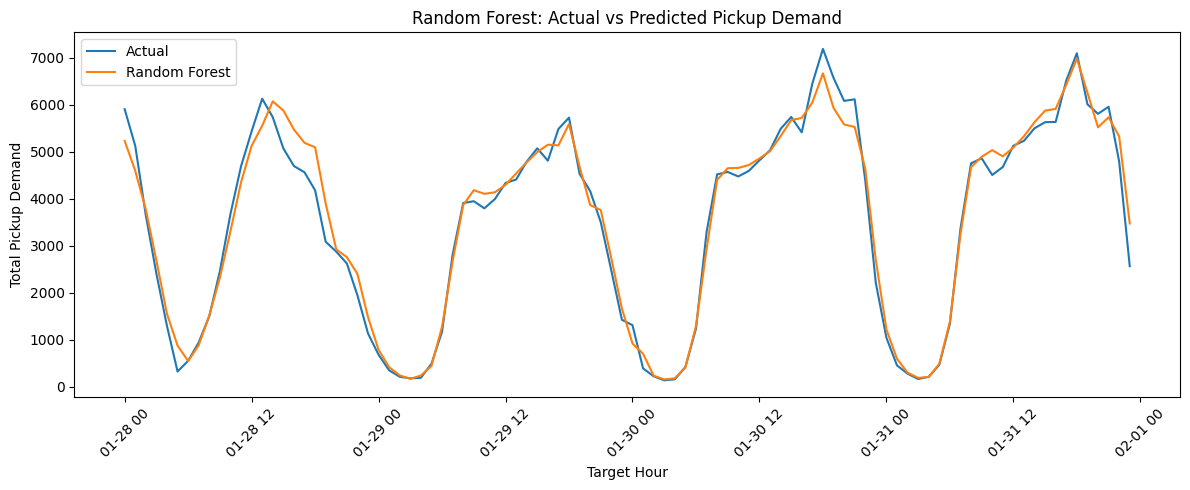

Figure saved: True


In [25]:
import matplotlib.pyplot as plt

# Aggregating actual and predicted demand by target hour
rf_hourly = (
    rf_test_predictions
    .groupby("target_hour")[[target_col, "rf_prediction"]]
    .sum()
    .reset_index()
)

# Plotting actual and predicted demand
plt.figure(figsize=(12, 5))

plt.plot(
    rf_hourly["target_hour"],
    rf_hourly[target_col],
    label="Actual"
)

plt.plot(
    rf_hourly["target_hour"],
    rf_hourly["rf_prediction"],
    label="Random Forest"
)

plt.xlabel("Target Hour")
plt.ylabel("Total Pickup Demand")
plt.title("Random Forest: Actual vs Predicted Pickup Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Saving the figure
rf_time_plot_path = (
    figures_dir / "zone_rf_actual_vs_predicted_time.png"
)

plt.savefig(rf_time_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", rf_time_plot_path.exists())

The Random Forest closely follows the observed hourly pickup-demand pattern across the test period, capturing both daily peaks and low-demand periods. Larger errors occur mainly around the sharpest demand peaks.

## Visualising Actual and Predicted Random Forest Demand

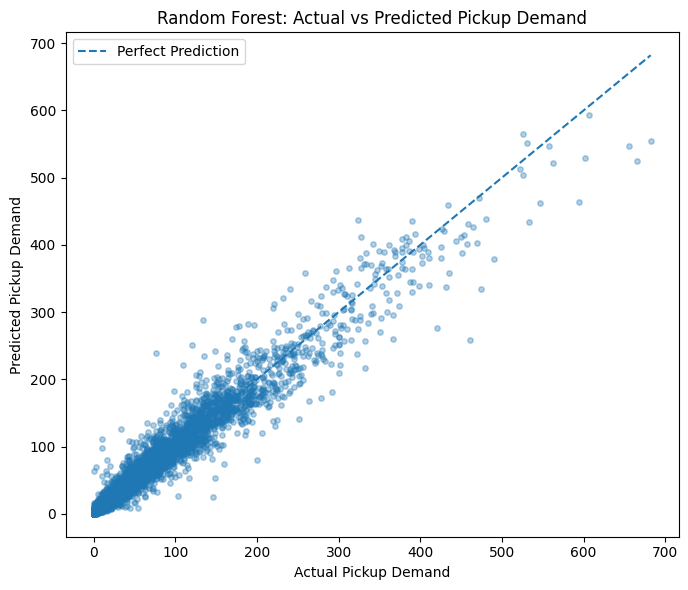

Figure saved: True


In [26]:
# Creating the actual vs predicted scatter plot
plt.figure(figsize=(7, 6))

plt.scatter(
    rf_test_predictions[target_col],
    rf_test_predictions["rf_prediction"],
    alpha=0.35,
    s=15
)

# Adding the perfect-prediction reference line
max_value = max(
    rf_test_predictions[target_col].max(),
    rf_test_predictions["rf_prediction"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Pickup Demand")
plt.ylabel("Predicted Pickup Demand")
plt.title("Random Forest: Actual vs Predicted Pickup Demand")
plt.legend()
plt.tight_layout()

# Saving the figure
rf_scatter_path = (
    figures_dir / "zone_rf_actual_vs_predicted_scatter.png"
)

plt.savefig(rf_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", rf_scatter_path.exists())

The Random Forest predictions closely follow the observed demand, although larger errors appear at the highest pickup-demand levels.

## Examining Random Forest Feature Importance

Examining the relative importance of the predictor variables used by the Random Forest model.

,Feature,Importance
0,pickup_count,0.898216
16,hour_cos,0.017455
10,rolling_mean_24h,0.013065
15,hour_sin,0.009182
6,lag_24h,0.008665
5,lag_12h,0.007132
9,rolling_mean_12h,0.006228
4,lag_6h,0.006011
1,lag_1h,0.005824
3,lag_3h,0.004871


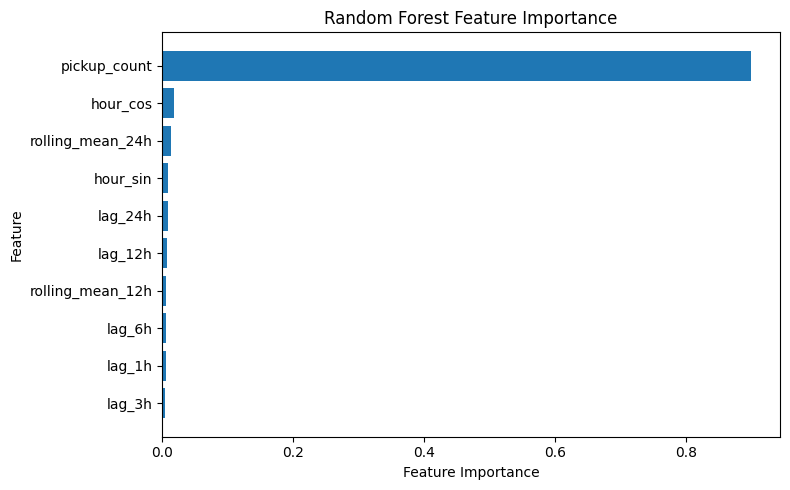

Figure saved: True


In [27]:
# Creating the feature-importance table
rf_feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_final_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_feature_importance.head(10))

# Plotting the 10 most important features
top_features = rf_feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

# Saving the figure
rf_importance_path = (
    figures_dir / "zone_rf_feature_importance.png"
)

plt.savefig(rf_importance_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", rf_importance_path.exists())

Current-hour pickup demand is the dominant Random Forest predictor, indicating strong short-term persistence in zone-level taxi demand.

## Preparing the LSTM Environment


In [29]:
# Importing the LSTM and scaling libraries
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

# Setting reproducible random seeds
np.random.seed(42)
tf.random.set_seed(42)

## Scaling the LSTM Data


In [33]:
# Sorting observations within each zone
lstm_data = (
    zone_model_data
    .sort_values(["LocationID", "pickup_hour"])
    .reset_index(drop=True)
    .copy()
)

# Identifying training observations
lstm_train_mask = lstm_data["data_split"].eq("Train")

# Creating separate feature and target scalers
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fitting the scalers using training data only
feature_scaler.fit(
    lstm_data.loc[lstm_train_mask, feature_cols]
)

target_scaler.fit(
    lstm_data.loc[lstm_train_mask, [target_col]]
)

# Scaling all observations using the training-fitted scalers
lstm_data[feature_cols] = feature_scaler.transform(
    lstm_data[feature_cols]
)

lstm_data["scaled_target"] = target_scaler.transform(
    lstm_data[[target_col]]
).ravel()

# Checking the scaled data
print("Training rows used for scaling:", lstm_train_mask.sum())
print("Missing scaled features:", lstm_data[feature_cols].isna().sum().sum())
print("Missing scaled targets:", lstm_data["scaled_target"].isna().sum())

print("Mean scaled training features:",round(lstm_data.loc[lstm_train_mask, feature_cols].to_numpy().mean(),6))

print("Mean scaled training target:",round(lstm_data.loc[lstm_train_mask, "scaled_target"].mean(),6 ))

Training rows used for scaling: 33728
Missing scaled features: 0
Missing scaled targets: 0
Mean scaled training features: 0.0
Mean scaled training target: 0.0


## Creating 24-Hour LSTM Sequences

Creating 24-hour input sequences separately within each taxi zone for one-hour-ahead demand forecasting.

In [34]:
# Setting the sequence length
sequence_length = 24

X_sequences = []
y_sequences = []
sequence_splits = []
sequence_metadata = []

# Creating sequences separately within each zone
for location_id, zone_group in lstm_data.groupby("LocationID", sort=False):

    zone_group = zone_group.sort_values("pickup_hour").reset_index(drop=True)

    zone_features = zone_group[feature_cols].to_numpy(dtype=np.float32)
    zone_targets = zone_group["scaled_target"].to_numpy(dtype=np.float32)

    for end_index in range(sequence_length - 1, len(zone_group)):

        start_index = end_index - sequence_length + 1

        X_sequences.append(zone_features[start_index:end_index + 1])

        y_sequences.append(zone_targets[end_index])

        sequence_splits.append(zone_group.loc[end_index, "data_split"])

        sequence_metadata.append({
            "LocationID": location_id,
            "Zone": zone_group.loc[end_index, "Zone"],
            "pickup_hour": zone_group.loc[end_index, "pickup_hour"],
            "target_hour": zone_group.loc[end_index, "target_hour"],
            "data_split": zone_group.loc[end_index, "data_split"],
            "actual_demand": zone_group.loc[end_index, target_col]
        })

# Converting to arrays
X_sequences = np.asarray(X_sequences, dtype=np.float32)
y_sequences = np.asarray(y_sequences, dtype=np.float32)
sequence_splits = np.asarray(sequence_splits)

lstm_metadata = pd.DataFrame(sequence_metadata)

# Creating split masks
train_seq_mask = sequence_splits == "Train"
val_seq_mask = sequence_splits == "Validation"
test_seq_mask = sequence_splits == "Test"

# Creating train, validation and test sequences
X_lstm_train = X_sequences[train_seq_mask]
y_lstm_train = y_sequences[train_seq_mask]

X_lstm_val = X_sequences[val_seq_mask]
y_lstm_val = y_sequences[val_seq_mask]

X_lstm_test = X_sequences[test_seq_mask]
y_lstm_test = y_sequences[test_seq_mask]

# Checking sequence shapes
print("Sequence length:", sequence_length)
print("Features per time step:", len(feature_cols))
print("Training:", X_lstm_train.shape, y_lstm_train.shape)
print("Validation:", X_lstm_val.shape, y_lstm_val.shape)
print("Test:", X_lstm_test.shape, y_lstm_test.shape)
print("Missing sequence values:", np.isnan(X_sequences).sum())
print("Zones represented:", lstm_metadata["LocationID"].nunique())

Sequence length: 24
Features per time step: 21
Training: (32256, 24, 21) (32256,)
Validation: (6144, 24, 21) (6144,)
Test: (6144, 24, 21) (6144,)
Missing sequence values: 0
Zones represented: 64


## Building the LSTM Model

Building the LSTM architecture for one-hour-ahead zone-level pickup-demand forecasting.

In [35]:
# Importing the input layer
from tensorflow.keras.layers import Input

# Building the LSTM model
lstm_model = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),
    LSTM(64),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1)
])

# Checking the model structure
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)

## Configuring LSTM Training

In [37]:
# Compiling the LSTM model
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

# Setting early stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Training the LSTM Model

Training the LSTM using the training sequences while monitoring performance on the validation period.

In [38]:
# Training the LSTM model
lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

# Checking the selected training length
print("Epochs completed:", len(lstm_history.history["loss"]))
print("Best validation loss:", round(min(lstm_history.history["val_loss"]), 6))

Epoch 1/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.1385 - mean_absolute_error: 0.2149 - val_loss: 0.0957 - val_mean_absolute_error: 0.1696
Epoch 2/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0772 - mean_absolute_error: 0.1635 - val_loss: 0.0777 - val_mean_absolute_error: 0.1574
Epoch 3/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0701 - mean_absolute_error: 0.1539 - val_loss: 0.0682 - val_mean_absolute_error: 0.1466
Epoch 4/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0656 - mean_absolute_error: 0.1478 - val_loss: 0.0662 - val_mean_absolute_error: 0.1448
Epoch 5/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0625 - mean_absolute_error: 0.1438 - val_loss: 0.0644 - val_mean_absolute_error: 0.1419
Epoch 6/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0603 - mean_absolute_error: 0.1402 - val_loss: 0.0637 - val_mean_absolute_error: 0.1436
Epoch 7/50
504/504 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0572 - mean_absolute_error: 0.1379 - v

Early stopping ended LSTM training after 17 epochs, retaining the model weights with the lowest validation loss.

## Visualising LSTM Training Performance

Comparing training and validation loss across epochs to assess model convergence and overfitting.

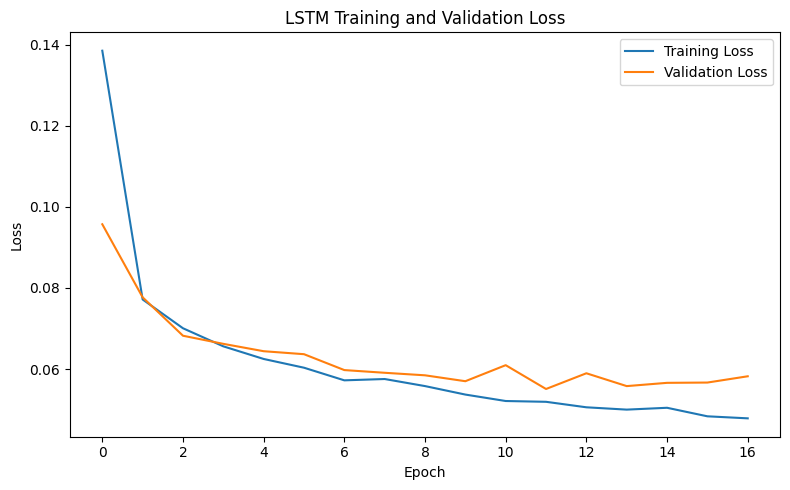

Figure saved: True


In [39]:
# Plotting training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.tight_layout()

# Saving the figure
lstm_loss_path = figures_dir / "zone_lstm_training_loss.png"

plt.savefig(lstm_loss_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", lstm_loss_path.exists())

Validation loss stabilised while training loss continued to decrease, with early stopping helping to limit overfitting.

## Evaluating LSTM Validation Performance

Evaluating one-hour-ahead LSTM predictions on the validation period using the original pickup-demand scale.

In [41]:
# Creating scaled validation predictions
lstm_val_pred_scaled = lstm_model.predict(
    X_lstm_val,
    verbose=0
).ravel()

# Converting predictions back to the original demand scale
lstm_val_pred = target_scaler.inverse_transform(
    lstm_val_pred_scaled.reshape(-1, 1)
).ravel()

# Preventing negative pickup-demand predictions
lstm_val_pred = np.maximum(lstm_val_pred, 0)

# Using the exact original validation targets
lstm_val_metadata = (
    lstm_metadata.loc[val_seq_mask]
    .reset_index(drop=True)
)

lstm_val_actual = (
    lstm_val_metadata["actual_demand"]
    .to_numpy()
)

# Evaluating validation performance
lstm_validation = evaluate_forecast(
    lstm_val_actual,
    lstm_val_pred
)

# Displaying results neatly
lstm_validation_results = pd.DataFrame(
    [lstm_validation],
    index=["Validation"]
).round(4)

lstm_validation_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Validation,10.3329,17.8328,0.957,16.3441,59.325


## Evaluating LSTM Test Performance

Evaluating one-hour-ahead LSTM predictions on the unseen test period using the original pickup-demand scale.

In [42]:
# Creating scaled test predictions
lstm_test_pred_scaled = lstm_model.predict(
    X_lstm_test,
    verbose=0
).ravel()

# Converting predictions back to the original demand scale
lstm_test_pred = target_scaler.inverse_transform(
    lstm_test_pred_scaled.reshape(-1, 1)
).ravel()

# Preventing negative pickup-demand predictions
lstm_test_pred = np.maximum(lstm_test_pred, 0)

# Using the exact original test targets
lstm_test_metadata = (
    lstm_metadata.loc[test_seq_mask]
    .reset_index(drop=True)
)

lstm_test_actual = (
    lstm_test_metadata["actual_demand"]
    .to_numpy()
)

# Evaluating test performance
lstm_test = evaluate_forecast(
    lstm_test_actual,
    lstm_test_pred
)

# Displaying results neatly
lstm_test_results = pd.DataFrame(
    [lstm_test],
    index=["Test"]
).round(4)

lstm_test_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Test,10.017,16.7051,0.9562,18.366,74.17


The LSTM achieved strong test performance, although Random Forest produced lower MAE and WMAPE.

## Selecting the Best LSTM Epoch

Identifying the training epoch with the lowest validation loss for final model retraining.

In [43]:
# Finding the epoch with the lowest validation loss
best_epoch = np.argmin(
    lstm_history.history["val_loss"]
) + 1

best_val_loss = min(
    lstm_history.history["val_loss"]
)

print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 6))

Best epoch: 12
Best validation loss: 0.055099


## Preparing the Final LSTM Training Data

Refitting the feature and target scalers using the combined training and validation periods for final LSTM training.

In [44]:
# Creating a fresh copy using the original unscaled values
final_lstm_data = (
    zone_model_data
    .sort_values(["LocationID", "pickup_hour"])
    .reset_index(drop=True)
    .copy()
)

# Selecting training and validation observations
train_val_mask = final_lstm_data["data_split"].isin(
    ["Train", "Validation"]
)

# Creating final scalers
final_feature_scaler = StandardScaler()
final_target_scaler = StandardScaler()

# Fitting scalers using training + validation data only
final_feature_scaler.fit(
    final_lstm_data.loc[train_val_mask, feature_cols]
)

final_target_scaler.fit(
    final_lstm_data.loc[train_val_mask, [target_col]]
)

# Scaling all observations
final_lstm_data[feature_cols] = final_feature_scaler.transform(
    final_lstm_data[feature_cols]
)

final_lstm_data["scaled_target"] = final_target_scaler.transform(
    final_lstm_data[[target_col]]
).ravel()

# Checking the final scaling
print("Training + validation rows:", train_val_mask.sum())
print("Test rows excluded from scaler fitting:", (~train_val_mask).sum())
print("Missing scaled features:", final_lstm_data[feature_cols].isna().sum().sum())
print("Missing scaled targets:", final_lstm_data["scaled_target"].isna().sum())

Training + validation rows: 39872
Test rows excluded from scaler fitting: 6144
Missing scaled features: 0
Missing scaled targets: 0


## Creating the Final LSTM Sequences

Creating 24-hour sequences for final LSTM training using the combined training and validation periods.

In [45]:
# Creating the final 24-hour sequences
final_X = []
final_y = []
final_splits = []
final_metadata = []

for location_id, zone_group in final_lstm_data.groupby("LocationID", sort=False):

    zone_group = zone_group.sort_values("pickup_hour").reset_index(drop=True)

    zone_features = zone_group[feature_cols].to_numpy(dtype=np.float32)
    zone_targets = zone_group["scaled_target"].to_numpy(dtype=np.float32)

    for end_index in range(sequence_length - 1, len(zone_group)):

        start_index = end_index - sequence_length + 1

        final_X.append(
            zone_features[start_index:end_index + 1]
        )

        final_y.append(
            zone_targets[end_index]
        )

        final_splits.append(
            zone_group.loc[end_index, "data_split"]
        )

        final_metadata.append({
            "LocationID": location_id,
            "Zone": zone_group.loc[end_index, "Zone"],
            "pickup_hour": zone_group.loc[end_index, "pickup_hour"],
            "target_hour": zone_group.loc[end_index, "target_hour"],
            "data_split": zone_group.loc[end_index, "data_split"],
            "actual_demand": zone_group.loc[end_index, target_col]
        })

# Converting to arrays
final_X = np.asarray(final_X, dtype=np.float32)
final_y = np.asarray(final_y, dtype=np.float32)
final_splits = np.asarray(final_splits)

final_lstm_metadata = pd.DataFrame(final_metadata)

# Creating final training and test masks
final_train_mask = np.isin(
    final_splits,
    ["Train", "Validation"]
)

final_test_mask = final_splits == "Test"

# Creating final training and test datasets
X_lstm_train_final = final_X[final_train_mask]
y_lstm_train_final = final_y[final_train_mask]

X_lstm_test_final = final_X[final_test_mask]
y_lstm_test_final = final_y[final_test_mask]

# Checking the final sequence datasets
print("Final training sequences:", X_lstm_train_final.shape)
print("Final test sequences:", X_lstm_test_final.shape)
print("Missing sequence values:", np.isnan(final_X).sum())
print("Zones represented:", final_lstm_metadata["LocationID"].nunique())

Final training sequences: (38400, 24, 21)
Final test sequences: (6144, 24, 21)
Missing sequence values: 0
Zones represented: 64


## Training the Final LSTM Model

Retraining the LSTM using the combined training and validation data for the selected number of epochs.

In [46]:
# Resetting random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Building the final LSTM with the same architecture
final_lstm_model = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),
    LSTM(64),
    Dropout(0.20),
    Dense(32, activation="relu"),
    Dense(1)
])

# Compiling the final model
final_lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

# Training for the selected number of epochs
final_lstm_history = final_lstm_model.fit(
    X_lstm_train_final,
    y_lstm_train_final,
    epochs=best_epoch,
    batch_size=64,
    verbose=1
)

print("Final LSTM epochs completed:", len(final_lstm_history.history["loss"]))

Epoch 1/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.1256 - mean_absolute_error: 0.2118
Epoch 2/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0748 - mean_absolute_error: 0.1625
Epoch 3/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0677 - mean_absolute_error: 0.1505
Epoch 4/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0630 - mean_absolute_error: 0.1445
Epoch 5/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0608 - mean_absolute_error: 0.1404
Epoch 6/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0592 - mean_absolute_error: 0.1382
Epoch 7/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0569 - mean_absolute_error: 0.1355
Epoch 8/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0552 - mean_absolute_error: 0.1336
Epoch 9/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0533 - mean_absolute_error: 0.1319
Epoch 10/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0527 - mean_absolute_error: 0.1305
Epoch 11/12
600/600 ━━━━━━━━━

## Evaluating the Final LSTM

Evaluating the retrained LSTM on the unseen test period to obtain the final zone-level forecasting performance.

In [47]:
# Creating final test predictions
final_lstm_pred_scaled = final_lstm_model.predict(
    X_lstm_test_final,
    verbose=0
).ravel()

# Converting predictions back to the original demand scale
final_lstm_pred = final_target_scaler.inverse_transform(
    final_lstm_pred_scaled.reshape(-1, 1)
).ravel()

# Preventing negative demand predictions
final_lstm_pred = np.maximum(final_lstm_pred, 0)

# Getting the exact original test targets
final_lstm_test_metadata = (
    final_lstm_metadata.loc[final_test_mask]
    .reset_index(drop=True)
)

final_lstm_actual = (
    final_lstm_test_metadata["actual_demand"]
    .to_numpy()
)

# Evaluating final test performance
final_lstm_test = evaluate_forecast(
    final_lstm_actual,
    final_lstm_pred
)

# Displaying results neatly
final_lstm_test_results = pd.DataFrame(
    [final_lstm_test],
    index=["Test"]
).round(4)

final_lstm_test_results

,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Test,9.3782,16.7557,0.9559,17.1947,48.9136


The final LSTM achieved strong test performance, with results comparable to the Random Forest across the main evaluation metrics.

## Saving the Final LSTM Results

In [48]:
# Setting output paths
lstm_model_path = models_dir / "zone_lstm_1h_2024_01.keras"
lstm_feature_scaler_path = models_dir / "zone_lstm_feature_scaler_2024_01.joblib"
lstm_target_scaler_path = models_dir / "zone_lstm_target_scaler_2024_01.joblib"
lstm_predictions_path = reports_dir / "zone_lstm_test_predictions.csv"

# Saving the final model and scalers
final_lstm_model.save(lstm_model_path)
joblib.dump(final_feature_scaler, lstm_feature_scaler_path)
joblib.dump(final_target_scaler, lstm_target_scaler_path)

# Creating the final test-prediction dataset
lstm_test_predictions = final_lstm_test_metadata[
    ["LocationID", "Zone", "pickup_hour", "target_hour", "actual_demand"]
].copy()

lstm_test_predictions["lstm_prediction"] = final_lstm_pred

# Saving predictions
lstm_test_predictions.to_csv(
    lstm_predictions_path,
    index=False
)

# Checking saved outputs
print("LSTM model saved:", lstm_model_path.exists())
print("Feature scaler saved:", lstm_feature_scaler_path.exists())
print("Target scaler saved:", lstm_target_scaler_path.exists())
print("Test predictions saved:", lstm_predictions_path.exists())
print("Prediction rows:", len(lstm_test_predictions))

LSTM model saved: True
Feature scaler saved: True
Target scaler saved: True
Test predictions saved: True
Prediction rows: 6144


## Visualising LSTM Predictions Over Time

Comparing observed and predicted hourly pickup demand across the Manhattan taxi zones during the test period.

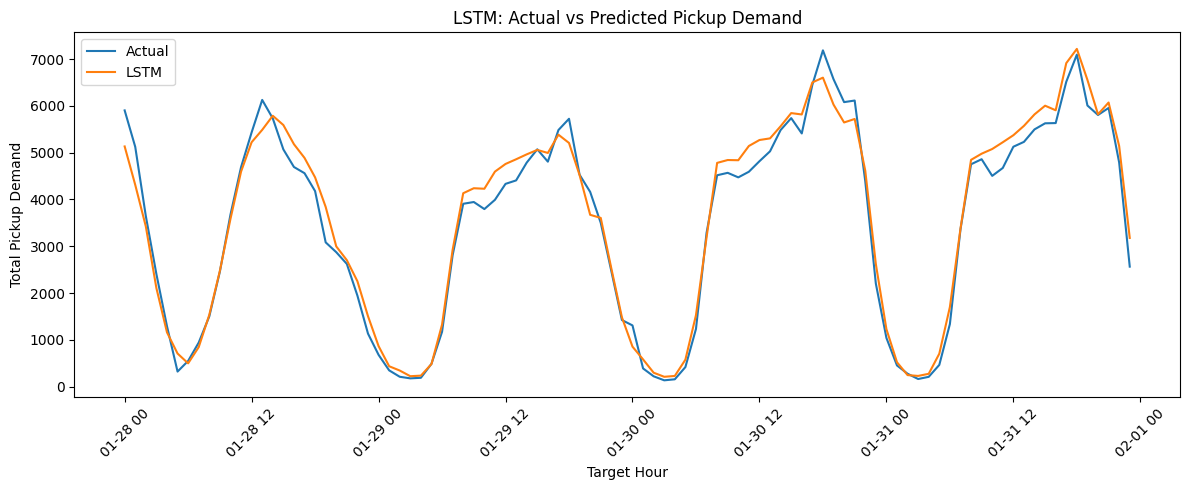

Figure saved: True


In [49]:
# Aggregating actual and predicted demand by target hour
lstm_hourly = (
    lstm_test_predictions
    .groupby("target_hour")[["actual_demand", "lstm_prediction"]]
    .sum()
    .reset_index()
)

# Plotting actual and predicted demand
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_hourly["target_hour"],
    lstm_hourly["actual_demand"],
    label="Actual"
)

plt.plot(
    lstm_hourly["target_hour"],
    lstm_hourly["lstm_prediction"],
    label="LSTM"
)

plt.xlabel("Target Hour")
plt.ylabel("Total Pickup Demand")
plt.title("LSTM: Actual vs Predicted Pickup Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

# Saving the figure
lstm_time_plot_path = (
    figures_dir / "zone_lstm_actual_vs_predicted_time.png"
)

plt.savefig(lstm_time_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", lstm_time_plot_path.exists())

The LSTM closely follows the observed hourly pickup-demand pattern, with only small deviations around some peak-demand periods.

## Visualising Actual and Predicted LSTM Demand

Comparing observed and predicted pickup demand across all zone-hour observations in the test period.

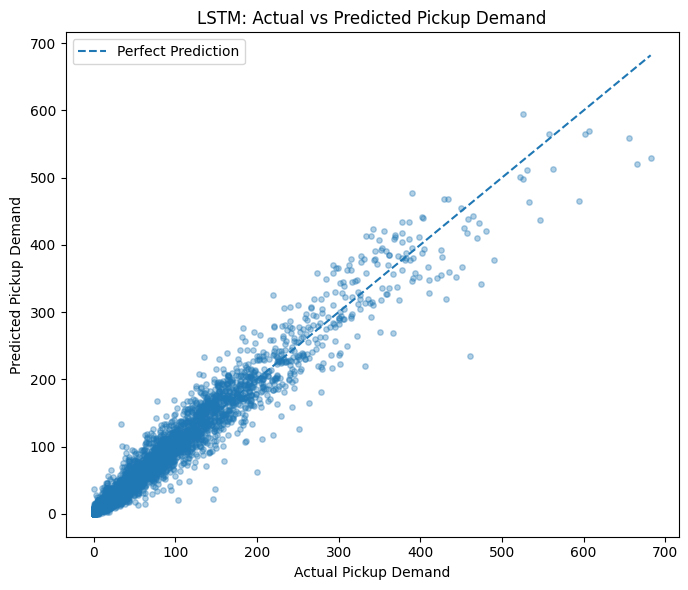

Figure saved: True


In [50]:
# Creating the LSTM actual vs predicted scatter plot
plt.figure(figsize=(7, 6))

plt.scatter(
    lstm_test_predictions["actual_demand"],
    lstm_test_predictions["lstm_prediction"],
    alpha=0.35,
    s=15
)

# Adding the perfect-prediction reference line
max_value = max(
    lstm_test_predictions["actual_demand"].max(),
    lstm_test_predictions["lstm_prediction"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Pickup Demand")
plt.ylabel("Predicted Pickup Demand")
plt.title("LSTM: Actual vs Predicted Pickup Demand")
plt.legend()
plt.tight_layout()

# Saving the figure
lstm_scatter_path = (
    figures_dir / "zone_lstm_actual_vs_predicted_scatter.png"
)

plt.savefig(lstm_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved:", lstm_scatter_path.exists())

# Zone-Level GAT-GRU model

## Loading Spatial Data for GAT-GRU

In [51]:
# Importing spatial and deep-learning libraries
import geopandas as gpd
import torch

# Setting the taxi-zone shapefile path
taxi_zones_path = spatial_dir / "taxi_zones" / "taxi_zones.shp"

# Loading the taxi-zone boundaries
taxi_zones = gpd.read_file(taxi_zones_path)

# Checking the spatial dataset
print("Shapefile exists:", taxi_zones_path.exists())
print("Spatial dataset shape:", taxi_zones.shape)
print("CRS:", taxi_zones.crs)
print("Missing LocationIDs:", taxi_zones["LocationID"].isna().sum())

Shapefile exists: True
Spatial dataset shape: (263, 7)
CRS: EPSG:2263
Missing LocationIDs: 0


## Selecting the GAT-GRU Zones

Filtering the spatial data to the same 64 main-Manhattan taxi zones used for zone-level forecasting.

In [52]:
# Selecting the same eligible Manhattan zones
gat_zones = (
    taxi_zones[
        taxi_zones["LocationID"].isin(
            eligible_manhattan_zones["LocationID"]
        )
    ]
    .sort_values("LocationID")
    .reset_index(drop=True)
    .copy()
)

# Checking the selected spatial zones
print("Selected spatial zones:", len(gat_zones))
print("Unique LocationIDs:", gat_zones["LocationID"].nunique())
print(
    "All expected zones included:",
    set(gat_zones["LocationID"])
    == set(eligible_manhattan_zones["LocationID"])
)

Selected spatial zones: 64
Unique LocationIDs: 64
All expected zones included: True


## Creating the Zone Neighbour Graph

Connecting Manhattan taxi zones that share a boundary to build the spatial graph for the GAT-GRU model.

In [53]:
# Creating a fixed node index for each LocationID
location_to_node = {
    location_id: node_index
    for node_index, location_id in enumerate(gat_zones["LocationID"])
}

# Creating edges between zones that share a boundary
edge_pairs = []

for i in range(len(gat_zones)):
    geometry_i = gat_zones.geometry.iloc[i]

    for j in range(i + 1, len(gat_zones)):
        geometry_j = gat_zones.geometry.iloc[j]

        if geometry_i.touches(geometry_j):
            # Adding both directions
            edge_pairs.append((i, j))
            edge_pairs.append((j, i))

# Converting edges to a PyTorch tensor
edge_index = torch.tensor(
    edge_pairs,
    dtype=torch.long
).t().contiguous()

# Calculating graph statistics
number_of_nodes = len(gat_zones)
number_of_directed_edges = edge_index.shape[1]
number_of_undirected_edges = number_of_directed_edges // 2

degree = torch.bincount(
    edge_index[0],
    minlength=number_of_nodes
)

print("Number of graph nodes:", number_of_nodes)
print("Number of undirected edges:", number_of_undirected_edges)
print("Number of directed edges:", number_of_directed_edges)
print("Minimum neighbours per zone:", degree.min().item())
print("Maximum neighbours per zone:", degree.max().item())
print("Average neighbours per zone:", round(degree.float().mean().item(), 2))
print("Zones with no neighbours:", int((degree == 0).sum().item()))

Number of graph nodes: 64
Number of undirected edges: 105
Number of directed edges: 210
Minimum neighbours per zone: 0
Maximum neighbours per zone: 7
Average neighbours per zone: 3.28
Zones with no neighbours: 4


## Connecting Isolated Zones

Connecting zones with no direct neighbour to their nearest taxi zone using spatial distance.

In [54]:
# Finding zones with no neighbours
isolated_nodes = torch.where(degree == 0)[0].tolist()

print("Isolated node indices:", isolated_nodes)

# Creating zone centre points
centroids = gat_zones.geometry.centroid

# Adding the nearest neighbour for each isolated zone
additional_edges = []

for node in isolated_nodes:

    centroid_i = centroids.iloc[node]

    # Calculating distance to every other zone
    distances = centroids.distance(centroid_i)
    distances.iloc[node] = np.inf

    # Finding the nearest zone
    nearest_node = distances.idxmin()

    # Adding the connection in both directions
    additional_edges.append((node, nearest_node))
    additional_edges.append((nearest_node, node))

    print(
        "Connected:",
        gat_zones.loc[node, "zone"],
        "->",
        gat_zones.loc[nearest_node, "zone"]
    )

# Combining original and new connections
edge_pairs_extended = edge_pairs + additional_edges
edge_pairs_extended = list(set(edge_pairs_extended))

# Rebuilding the graph edge tensor
edge_index = torch.tensor(
    edge_pairs_extended,
    dtype=torch.long
).t().contiguous()

# Rechecking neighbours
degree = torch.bincount(
    edge_index[0],
    minlength=number_of_nodes
)

print("\nUpdated graph:")
print("Nodes:", number_of_nodes)
print("Undirected connections:", edge_index.shape[1] // 2)
print("Minimum neighbours:", degree.min().item())
print("Maximum neighbours:", degree.max().item())
print("Average neighbours:", round(degree.float().mean().item(), 2))
print("Zones with no neighbours:", int((degree == 0).sum().item()))

Isolated node indices: [21, 25, 35, 57]
Connected: Hamilton Heights -> Manhattanville
Connected: Inwood Hill Park -> Inwood
Connected: Marble Hill -> Inwood Hill Park
Connected: Washington Heights North -> Highbridge Park

Updated graph:
Nodes: 64
Undirected connections: 109
Minimum neighbours: 1
Maximum neighbours: 7
Average neighbours: 3.41
Zones with no neighbours: 0


## Visualising the Zone Neighbour Graph


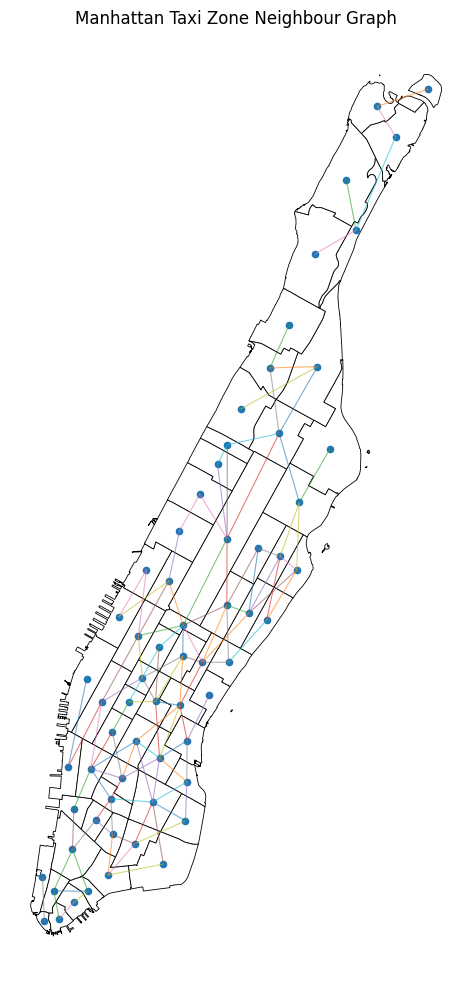

Figure saved: True


In [56]:
# Creating zone centre points
graph_centroids = gat_zones.geometry.centroid

# Creating the base Manhattan zone map
fig, ax = plt.subplots(figsize=(8, 10))

gat_zones.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black",
    linewidth=0.6
)

# Drawing the connections between zones
for source, target in edge_pairs_extended:

    if source < target:

        ax.plot(
            [
                graph_centroids.iloc[source].x,
                graph_centroids.iloc[target].x
            ],
            [
                graph_centroids.iloc[source].y,
                graph_centroids.iloc[target].y
            ],
            linewidth=0.8,
            alpha=0.6
        )

# Showing each taxi zone as a node
ax.scatter(
    graph_centroids.x,
    graph_centroids.y,
    s=20
)

ax.set_title("Manhattan Taxi Zone Neighbour Graph")
ax.set_axis_off()

plt.tight_layout()

# Saving the figure
zone_graph_path = figures_dir / "zone_gat_gru_neighbour_graph.png"
plt.savefig(zone_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", zone_graph_path.exists())

## Checking Graph Connections

Checking whether all 64 Manhattan taxi zones belong to one connected graph.

In [57]:
import networkx as nx

# Creating an undirected graph
G = nx.Graph()

# Adding all zone nodes
G.add_nodes_from(range(number_of_nodes))

# Adding the zone connections
for source, target in edge_pairs_extended:
    G.add_edge(source, target)

# Checking the graph
self_loops = list(nx.selfloop_edges(G))
connected_components = list(nx.connected_components(G))

print("Number of nodes:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())
print("Self-loops:", len(self_loops))
print("Connected groups:", len(connected_components))
print("Largest group:", max(len(group) for group in connected_components))
print("All zones connected:", nx.is_connected(G))

Number of nodes: 64
Number of connections: 109
Self-loops: 0
Connected groups: 3
Largest group: 56
All zones connected: False


## Checking the Separate Zone Groups

Checking which taxi zones belong to each disconnected part of the spatial graph.

In [58]:
# Sorting graph groups from largest to smallest
connected_components = sorted(
    nx.connected_components(G),
    key=len,
    reverse=True
)

# Showing the zones in each group
for group_number, component in enumerate(connected_components, start=1):
    component_nodes = sorted(component)

    component_zones = gat_zones.loc[
        component_nodes,
        ["LocationID", "zone"]
    ]

    print(f"\nGroup {group_number}: {len(component_nodes)} zones")
    display(component_zones)


Group 1: 56 zones


,LocationID,zone
0,4,Alphabet City
3,24,Bloomingdale
4,41,Central Harlem
5,42,Central Harlem North
6,43,Central Park
7,45,Chinatown
8,48,Clinton East
9,50,Clinton West
10,68,East Chelsea
11,74,East Harlem North



Group 2: 6 zones


,LocationID,zone
22,120,Highbridge Park
24,127,Inwood
25,128,Inwood Hill Park
35,153,Marble Hill
57,243,Washington Heights North
58,244,Washington Heights South



Group 3: 2 zones


,LocationID,zone
1,12,Battery Park
2,13,Battery Park City


## Connecting the Separate Zone Groups

Connecting the separate parts of the graph using the closest taxi zones.

In [59]:
# Creating a copy of the current graph
G_connected = G.copy()

# Storing the new connections
bridge_edges = []

# Connecting groups until the graph becomes fully connected
while not nx.is_connected(G_connected):

    components = list(nx.connected_components(G_connected))

    best_distance = np.inf
    best_pair = None

    # Comparing zones from different groups
    for i in range(len(components)):
        for j in range(i + 1, len(components)):

            for node_a in components[i]:
                geometry_a = gat_zones.geometry.iloc[node_a]

                for node_b in components[j]:
                    geometry_b = gat_zones.geometry.iloc[node_b]

                    distance = geometry_a.distance(geometry_b)

                    if distance < best_distance:
                        best_distance = distance
                        best_pair = (node_a, node_b)

    # Adding the closest connection
    node_a, node_b = best_pair

    G_connected.add_edge(node_a, node_b)
    bridge_edges.append((node_a, node_b))

    print(
        "Connected:",
        gat_zones.loc[node_a, "zone"],
        "<->",
        gat_zones.loc[node_b, "zone"],
        "| Distance:",
        round(best_distance, 2)
    )

# Adding the new connections in both directions
for node_a, node_b in bridge_edges:
    edge_pairs_extended.append((node_a, node_b))
    edge_pairs_extended.append((node_b, node_a))

# Removing duplicate connections
edge_pairs_extended = list(set(edge_pairs_extended))

# Rebuilding the PyTorch edge tensor
edge_index = torch.tensor(
    edge_pairs_extended,
    dtype=torch.long
).t().contiguous()

# Checking the final graph
print("\nFinal graph:")
print("Number of nodes:", G_connected.number_of_nodes())
print("Number of connections:", G_connected.number_of_edges())
print("Connected groups:", nx.number_connected_components(G_connected))
print("All zones connected:", nx.is_connected(G_connected))
print("New connections added:", len(bridge_edges))

Connected: Financial District South <-> Battery Park | Distance: 0.0
Connected: Central Harlem North <-> Highbridge Park | Distance: 0.0

Final graph:
Number of nodes: 64
Number of connections: 111
Connected groups: 1
All zones connected: True
New connections added: 2


## Preparing the GAT-GRU Data

Matching the hourly demand data with the fixed order of the 64 taxi-zone graph nodes.

In [60]:
# Creating the fixed graph-node zone order
node_location_ids = gat_zones["LocationID"].astype(int).tolist()

# Getting the available hourly timestamps
unique_pickup_hours = sorted(
    zone_model_data["pickup_hour"].unique()
)

# Checking observations at each hour
rows_per_hour = (
    zone_model_data
    .groupby("pickup_hour")
    .size()
)

# Checking that every hour contains the same 64 zones
expected_zones = set(node_location_ids)

all_hours_have_same_zones = all(
    set(group["LocationID"].astype(int)) == expected_zones
    for _, group in zone_model_data.groupby("pickup_hour")
)

print("Graph nodes:", len(node_location_ids))
print("Unique pickup hours:", len(unique_pickup_hours))
print("Minimum zones per hour:", rows_per_hour.min())
print("Maximum zones per hour:", rows_per_hour.max())
print("Every hour contains all 64 zones:", all_hours_have_same_zones)
print(
    "Graph and dataset zones match:",
    set(node_location_ids)
    == set(zone_model_data["LocationID"].astype(int).unique())
)

Graph nodes: 64
Unique pickup hours: 719
Minimum zones per hour: 64
Maximum zones per hour: 64
Every hour contains all 64 zones: True
Graph and dataset zones match: True


## Creating the GAT-GRU Data Tensors

Arranging the hourly data into a fixed time, zone and feature structure for GAT-GRU modelling.

In [61]:
# Creating the fixed node index
node_map = {
    location_id: index
    for index, location_id in enumerate(node_location_ids)
}

gat_data = zone_model_data.copy()
gat_data["node_index"] = gat_data["LocationID"].map(node_map)

# Sorting by hour and graph-node order
gat_data = (
    gat_data
    .sort_values(["pickup_hour", "node_index"])
    .reset_index(drop=True)
)

# Creating the feature tensor
X_all = (
    gat_data[feature_cols]
    .to_numpy(dtype=np.float32)
    .reshape(
        len(unique_pickup_hours),
        len(node_location_ids),
        len(feature_cols)
    )
)

# Creating the target tensor
y_all = (
    gat_data[target_col]
    .to_numpy(dtype=np.float32)
    .reshape(
        len(unique_pickup_hours),
        len(node_location_ids)
    )
)

# Checking the tensors
print("Missing node indices:", gat_data["node_index"].isna().sum())
print("Feature tensor shape:", X_all.shape)
print("Target tensor shape:", y_all.shape)
print("Missing feature values:", np.isnan(X_all).sum())
print("Missing target values:", np.isnan(y_all).sum())

Missing node indices: 0
Feature tensor shape: (719, 64, 21)
Target tensor shape: (719, 64)
Missing feature values: 0
Missing target values: 0


## Creating 24-Hour GAT-GRU Sequences

Creating 24-hour historical sequences for one-hour-ahead pickup-demand forecasting.

In [62]:
# Setting the sequence length
sequence_length = 24

# Creating containers
X_sequences = []
y_sequences = []
sequence_target_hours = []

# Creating 24-hour sequences
for end_index in range(sequence_length - 1, len(X_all)):

    start_index = end_index - sequence_length + 1

    # Using the previous 24 hours
    X_sequences.append(
        X_all[start_index:end_index + 1]
    )

    # Saving the one-hour-ahead target
    y_sequences.append(
        y_all[end_index]
    )

    # Saving the target hour
    sequence_target_hours.append(
        gat_data.loc[
            end_index * len(node_location_ids),
            "target_hour"
        ]
    )

# Converting to arrays
X_sequences = np.asarray(X_sequences, dtype=np.float32)
y_sequences = np.asarray(y_sequences, dtype=np.float32)
sequence_target_hours = pd.to_datetime(sequence_target_hours)

# Checking the sequences
print("Sequence feature shape:", X_sequences.shape)
print("Sequence target shape:", y_sequences.shape)
print("Number of target hours:", len(sequence_target_hours))
print("First target hour:", sequence_target_hours.min())
print("Last target hour:", sequence_target_hours.max())
print("Missing sequence features:", np.isnan(X_sequences).sum())
print("Missing sequence targets:", np.isnan(y_sequences).sum())

Sequence feature shape: (696, 24, 64, 21)
Sequence target shape: (696, 64)
Number of target hours: 696
First target hour: 2024-01-03 00:00:00
Last target hour: 2024-01-31 23:00:00
Missing sequence features: 0
Missing sequence targets: 0


## Creating Time-Based GAT-GRU Splits

Dividing the GAT-GRU sequences into training, validation and test periods using the forecast target hour.

In [63]:
# Setting the split dates
validation_start = pd.Timestamp("2024-01-24 00:00:00")
test_start = pd.Timestamp("2024-01-28 00:00:00")
test_end = pd.Timestamp("2024-02-01 00:00:00")

# Creating the split masks
train_mask = sequence_target_hours < validation_start

validation_mask = (
    (sequence_target_hours >= validation_start)
    & (sequence_target_hours < test_start)
)

test_mask = (
    (sequence_target_hours >= test_start)
    & (sequence_target_hours < test_end)
)

# Creating the datasets
X_train = X_sequences[train_mask]
y_train = y_sequences[train_mask]

X_validation = X_sequences[validation_mask]
y_validation = y_sequences[validation_mask]

X_test = X_sequences[test_mask]
y_test = y_sequences[test_mask]

# Saving the target hours
train_target_hours = sequence_target_hours[train_mask]
validation_target_hours = sequence_target_hours[validation_mask]
test_target_hours = sequence_target_hours[test_mask]

# Checking the splits
print("Training sequences:", X_train.shape)
print("Validation sequences:", X_validation.shape)
print("Test sequences:", X_test.shape)

print("\nTraining period:", train_target_hours.min(), "to", train_target_hours.max())
print("Validation period:", validation_target_hours.min(), "to", validation_target_hours.max())
print("Test period:", test_target_hours.min(), "to", test_target_hours.max())

print("\nTotal sequences:", len(X_train) + len(X_validation) + len(X_test))

Training sequences: (504, 24, 64, 21)
Validation sequences: (96, 24, 64, 21)
Test sequences: (96, 24, 64, 21)

Training period: 2024-01-03 00:00:00 to 2024-01-23 23:00:00
Validation period: 2024-01-24 00:00:00 to 2024-01-27 23:00:00
Test period: 2024-01-28 00:00:00 to 2024-01-31 23:00:00

Total sequences: 696


## Scaling the GAT-GRU Data

Scaling the input features and target values using information from the training period only.


In [65]:
# Selecting original training rows for fitting the scalers
training_rows = zone_model_data[
    zone_model_data["target_hour"] < validation_start
].copy()

# Creating the scalers
gat_feature_scaler = StandardScaler()
gat_target_scaler = StandardScaler()

# Fitting the scalers using training data only
gat_feature_scaler.fit(training_rows[feature_cols].to_numpy())

gat_target_scaler.fit(training_rows[[target_col]].to_numpy())

# Scaling the feature sequences
X_train_scaled = gat_feature_scaler.transform(X_train.reshape(-1, len(feature_cols))).reshape(X_train.shape)

X_validation_scaled = gat_feature_scaler.transform( X_validation.reshape(-1, len(feature_cols))).reshape(X_validation.shape)

X_test_scaled = gat_feature_scaler.transform(X_test.reshape(-1, len(feature_cols))).reshape(X_test.shape)

# Scaling the targets
y_train_scaled = gat_target_scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)

y_validation_scaled = gat_target_scaler.transform(y_validation.reshape(-1, 1)).reshape(y_validation.shape)

y_test_scaled = gat_target_scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Checking the scaled data
print("Training features:", X_train_scaled.shape)
print("Validation features:", X_validation_scaled.shape)
print("Test features:", X_test_scaled.shape)

print("\nTraining targets:", y_train_scaled.shape)
print("Validation targets:", y_validation_scaled.shape)
print("Test targets:", y_test_scaled.shape)

print("\nMissing scaled features:",
      np.isnan(X_train_scaled).sum()
      + np.isnan(X_validation_scaled).sum()
      + np.isnan(X_test_scaled).sum())

print("Missing scaled targets:",
      np.isnan(y_train_scaled).sum()
      + np.isnan(y_validation_scaled).sum()
      + np.isnan(y_test_scaled).sum())

Training features: (504, 24, 64, 21)
Validation features: (96, 24, 64, 21)
Test features: (96, 24, 64, 21)

Training targets: (504, 64)
Validation targets: (96, 64)
Test targets: (96, 64)

Missing scaled features: 0
Missing scaled targets: 0


The GAT-GRU scalers were fitted using training data only, keeping validation and test information separate from model preparation.

## Creating the PyTorch Tensors

Converting the scaled zone-level sequences and targets into PyTorch tensors for GAT-GRU modelling.

In [66]:
# Selecting the computing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Converting feature arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_validation_tensor = torch.tensor(X_validation_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Converting target arrays to PyTorch tensors
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Moving the graph connections to the selected device
edge_index = edge_index.to(device)

# Checking the tensor shapes
print("\nTraining features:", X_train_tensor.shape)
print("Validation features:", X_validation_tensor.shape)
print("Test features:", X_test_tensor.shape)

print("\nTraining targets:", y_train_tensor.shape)
print("Validation targets:", y_validation_tensor.shape)
print("Test targets:", y_test_tensor.shape)

print("\nEdge index shape:", edge_index.shape)

Using device: cpu

Training features: torch.Size([504, 24, 64, 21])
Validation features: torch.Size([96, 24, 64, 21])
Test features: torch.Size([96, 24, 64, 21])

Training targets: torch.Size([504, 64])
Validation targets: torch.Size([96, 64])
Test targets: torch.Size([96, 64])

Edge index shape: torch.Size([2, 222])


## Defining the Zone-Level GAT-GRU Model

Combining 24-hour temporal learning with spatial information from neighbouring Manhattan taxi zones.

In [69]:
# Importing PyTorch neural-network tools
import torch.nn as nn
from torch_geometric.nn import GATConv


# Defining the zone-level GAT-GRU model
class ZoneGATGRU(nn.Module):

    def __init__(
        self,
        input_size,
        gru_hidden_size=64,
        gat_hidden_size=32,
        gat_heads=2,
        dropout=0.2
    ):
        super().__init__()

        # Learning temporal patterns for each zone
        self.gru = nn.GRU(input_size=input_size,hidden_size=gru_hidden_size,batch_first=True)

        # Learning information from neighbouring zones
        self.gat = GATConv(
            in_channels=gru_hidden_size,
            out_channels=gat_hidden_size,
            heads=gat_heads,
            concat=True,
            dropout=dropout
        )

        # Creating the prediction layers
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(
            gat_hidden_size * gat_heads,
            32
        )
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):

        # x shape:
        # batch × sequence × zones × features
        batch_size, sequence_length, number_of_nodes, number_of_features = x.shape

        # Rearranging so each zone has its own 24-hour sequence
        x = x.permute(0, 2, 1, 3)

        x = x.reshape(batch_size * number_of_nodes,sequence_length,number_of_features)

        # Learning the 24-hour temporal pattern
        _, hidden = self.gru(x)

        # Restoring the zone structure
        node_embeddings = hidden[-1].reshape(batch_size,number_of_nodes,-1)

        predictions = []

        # Applying the same zone graph to each sequence
        for batch_index in range(batch_size):

            # Learning from neighbouring zones
            graph_features = self.gat(node_embeddings[batch_index],edge_index)

            graph_features = self.relu(graph_features)
            graph_features = self.dropout(graph_features)

            # Creating the final demand prediction
            graph_features = self.relu(self.fc1(graph_features))

            zone_predictions = self.fc2(graph_features).squeeze(-1)

            predictions.append(zone_predictions)

        # Returning predictions for all sequences and zones
        return torch.stack(predictions, dim=0)

## Creating and Checking the GAT-GRU Model

Creating the GAT-GRU model and checking that it produces the expected zone-level prediction shape.

In [70]:
# Creating the GAT-GRU model
model = ZoneGATGRU(
    input_size=len(feature_cols),
    gru_hidden_size=64,
    gat_hidden_size=32,
    gat_heads=2,
    dropout=0.2
).to(device)

print(model)

# Counting trainable parameters
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("\nTrainable parameters:", f"{trainable_parameters:,}")

# Checking a small forward pass
model.eval()

with torch.no_grad():
    sample_input = X_train_tensor[:2].to(device)
    sample_output = model(sample_input, edge_index)

print("\nSample input shape:", sample_input.shape)
print("Sample output shape:", sample_output.shape)

ZoneGATGRU(
  (gru): GRU(21, 64, batch_first=True)
  (gat): GATConv(64, 32, heads=2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Trainable parameters: 23,105

Sample input shape: torch.Size([2, 24, 64, 21])
Sample output shape: torch.Size([2, 64])


## Configuring the GAT-GRU Training

Setting the training parameters, loss function, optimiser and data loaders for the zone-level GAT-GRU model.

In [71]:
# Importing PyTorch data-loading tools
from torch.utils.data import TensorDataset, DataLoader

# Setting reproducibility
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Setting the training parameters
MAX_EPOCHS = 30
BATCH_SIZE = 1
INITIAL_LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 5
GRADIENT_CLIP_NORM = 1.0

# Using Huber loss
criterion = nn.HuberLoss()

# Creating the optimiser
optimizer = torch.optim.Adam(model.parameters(),lr=INITIAL_LEARNING_RATE)

# Reducing the learning rate when validation loss stops improving
learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

# Creating datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Creating data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Checking the training configuration
print("Maximum epochs:", MAX_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Initial learning rate:", INITIAL_LEARNING_RATE)
print("Loss function:", criterion)
print("Early-stopping patience:", EARLY_STOPPING_PATIENCE)
print("Gradient clipping norm:", GRADIENT_CLIP_NORM)

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Maximum epochs: 30
Batch size: 1
Initial learning rate: 0.001
Loss function: HuberLoss()
Early-stopping patience: 5
Gradient clipping norm: 1.0

Training batches: 504
Validation batches: 96
Test batches: 96


The GAT-GRU uses Huber loss with the Adam optimiser, while learning-rate reduction, early stopping and gradient clipping are used to support stable training.

## Testing a Single Training Batch

Testing one training batch to confirm that the GAT-GRU can complete the full training process successfully.

In [72]:
# Switching the model to training mode
model.train()

# Getting one training batch
batch_X, batch_y = next(iter(train_loader))

batch_X = batch_X.to(device)
batch_y = batch_y.to(device)

# Clearing previous gradients
optimizer.zero_grad()

# Creating predictions
batch_predictions = model(
    batch_X,
    edge_index
)

# Calculating the loss
batch_loss = criterion(
    batch_predictions,
    batch_y
)

# Performing backpropagation
batch_loss.backward()

# Clipping large gradients
torch.nn.utils.clip_grad_norm_(
    model.parameters(),
    GRADIENT_CLIP_NORM)

# Updating the model parameters
optimizer.step()

# Checking the batch
print("Batch input shape:", batch_X.shape)
print("Batch target shape:", batch_y.shape)
print("Batch prediction shape:", batch_predictions.shape)
print("Single-batch loss:", batch_loss.item())

Batch input shape: torch.Size([1, 24, 64, 21])
Batch target shape: torch.Size([1, 64])
Batch prediction shape: torch.Size([1, 64])
Single-batch loss: 0.575541615486145


## Training the GAT-GRU Model

Training the GAT-GRU using the chronological training and validation sequences, while retaining the model with the lowest validation loss.

In [73]:
import copy
import time

# Resetting the random seeds
np.random.seed(42)
torch.manual_seed(42)

# Creating a fresh model after the single-batch test
model = ZoneGATGRU(
    input_size=len(feature_cols),
    gru_hidden_size=64,
    gat_hidden_size=32,
    gat_heads=2,
    dropout=0.2
).to(device)

# Recreating the loss function and optimiser
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=INITIAL_LEARNING_RATE
)

# Recreating the learning-rate scheduler
learning_rate_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

# Preparing the training history
training_losses = []
validation_losses = []

best_validation_loss = np.inf
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

training_start_time = time.time()

# Training the model
for epoch in range(1, MAX_EPOCHS + 1):

 # Training

    model.train()
    epoch_training_loss = 0.0

    for batch_X, batch_y in train_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(
            batch_X,
            edge_index
        )

        loss = criterion(
            predictions,
            batch_y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRADIENT_CLIP_NORM
        )

        optimizer.step()

        epoch_training_loss += loss.item()

    average_training_loss = (
        epoch_training_loss / len(train_loader)
    )

    
# Validation

    model.eval()
    epoch_validation_loss = 0.0

    with torch.no_grad():

        for batch_X, batch_y in validation_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(
                batch_X,
                edge_index
            )

            loss = criterion(
                predictions,
                batch_y
            )

            epoch_validation_loss += loss.item()

    average_validation_loss = (
        epoch_validation_loss / len(validation_loader)
    )

    # Saving the epoch losses
    training_losses.append(average_training_loss)
    validation_losses.append(average_validation_loss)

    # Updating the learning rate
    learning_rate_scheduler.step(
        average_validation_loss
    )

    # Checking for validation improvement
    if average_validation_loss < best_validation_loss:

        best_validation_loss = average_validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {average_training_loss:.6f} | "
        f"Val Loss: {average_validation_loss:.6f} | "
        f"LR: {current_learning_rate:.6f}"
    )

    # Applying early stopping
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}."
        )
        break

# Restoring the best model
model.load_state_dict(best_model_state)

training_minutes = (
    time.time() - training_start_time
) / 60

print("\nBest epoch:", best_epoch)
print(
    "Best validation loss:",
    round(best_validation_loss, 6)
)
print(
    "Training time:",
    round(training_minutes, 2),
    "minutes"
)

# Saving the best validation model
gat_gru_model_path = (
    models_dir / "zone_gat_gru_1h_2024_01.pt"
)

torch.save(
    model.state_dict(),
    gat_gru_model_path
)

print(
    "Model saved:",
    gat_gru_model_path.exists()
)

Epoch 01 | Train Loss: 0.139889 | Val Loss: 0.129219 | LR: 0.001000
Epoch 02 | Train Loss: 0.102253 | Val Loss: 0.102697 | LR: 0.001000
Epoch 03 | Train Loss: 0.089679 | Val Loss: 0.091033 | LR: 0.001000
Epoch 04 | Train Loss: 0.081612 | Val Loss: 0.082846 | LR: 0.001000
Epoch 05 | Train Loss: 0.077413 | Val Loss: 0.079931 | LR: 0.001000
Epoch 06 | Train Loss: 0.072113 | Val Loss: 0.074545 | LR: 0.001000
Epoch 07 | Train Loss: 0.068883 | Val Loss: 0.070047 | LR: 0.001000
Epoch 08 | Train Loss: 0.066362 | Val Loss: 0.063436 | LR: 0.001000
Epoch 09 | Train Loss: 0.064351 | Val Loss: 0.064688 | LR: 0.001000
Epoch 10 | Train Loss: 0.062580 | Val Loss: 0.073368 | LR: 0.001000
Epoch 11 | Train Loss: 0.062902 | Val Loss: 0.063693 | LR: 0.000500
Epoch 12 | Train Loss: 0.054426 | Val Loss: 0.056194 | LR: 0.000500
Epoch 13 | Train Loss: 0.053475 | Val Loss: 0.053299 | LR: 0.000500
Epoch 14 | Train Loss: 0.052484 | Val Loss: 0.054771 | LR: 0.000500
Epoch 15 | Train Loss: 0.050841 | Val Loss: 0.07

The GAT-GRU achieved its lowest validation loss at epoch 22. Early stopping ended training at epoch 27 and restored the best-performing model weights.

## Evaluating the GAT-GRU on the Validation Set

Evaluating the best validation-selected GAT-GRU model using the zone-level forecasting metrics.

In [74]:
# Creating validation predictions
model.eval()
validation_predictions_scaled = []

with torch.no_grad():
    for batch_X, _ in validation_loader:
        batch_X = batch_X.to(device)

        predictions = model(
            batch_X,
            edge_index
        )

        validation_predictions_scaled.append(
            predictions.cpu().numpy()
        )

# Combining all validation predictions
validation_predictions_scaled = np.concatenate(validation_predictions_scaled,axis=0)

# Transforming predictions back to pickup-demand scale
validation_predictions = gat_target_scaler.inverse_transform(
    validation_predictions_scaled.reshape(-1, 1)
).reshape(validation_predictions_scaled.shape)

# Counting and clipping negative predictions
negative_predictions = int((validation_predictions < 0).sum())

validation_predictions = np.clip(validation_predictions,0, None)

# Using the original unscaled validation targets
validation_actual = y_validation.copy()

# Flattening all 64 zones for overall evaluation
validation_actual_flat = validation_actual.ravel()
validation_predictions_flat = validation_predictions.ravel()

# Calculating validation metrics
validation_metrics = evaluate_forecast(
    validation_actual_flat,
    validation_predictions_flat
)

validation_results = pd.DataFrame(
    [validation_metrics],
    index=["GAT-GRU"]
)

print("Number of validation predictions:", len(validation_predictions_flat))
print("Negative predictions before clipping:", negative_predictions)

print("\nGAT-GRU validation performance:")
display(validation_results.round(4))

Number of validation predictions: 6144
Negative predictions before clipping: 0

GAT-GRU validation performance:


,MAE,RMSE,R2,WMAPE,MAPE_nonzero
GAT-GRU,14.4043,23.4525,0.9256,22.784,90.733299


The GAT-GRU achieved strong validation performance with an R² of 0.926 and a WMAPE of 22.78%. The higher non-zero MAPE reflects larger percentage errors for low-demand observations.

## Combining Training and Validation Data

Combining the training and validation sequences for final GAT-GRU model training while keeping the test period separate.

In [75]:
# Combining training and validation sequences
X_train_validation_tensor = torch.cat(
    [
        X_train_tensor,
        X_validation_tensor
    ],
    dim=0
)

y_train_validation_tensor = torch.cat(
    [
        y_train_tensor,
        y_validation_tensor
    ],
    dim=0
)

# Creating the combined dataset
train_validation_dataset = TensorDataset(
    X_train_validation_tensor,
    y_train_validation_tensor
)

train_validation_loader = DataLoader(
    train_validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# Checking the combined data
print("Combined training + validation sequences:",X_train_validation_tensor.shape)

print("Combined targets:",y_train_validation_tensor.shape)

print("Training batches:",len(train_validation_loader))

Combined training + validation sequences: torch.Size([600, 24, 64, 21])
Combined targets: torch.Size([600, 64])
Training batches: 600


Training and validation data are combined only after selecting the best epoch, while the test period remains separate for final evaluation.

## Training the Final GAT-GRU Model

Retraining a fresh GAT-GRU using the combined training and validation data for the selected number of epochs.

In [76]:
# Resetting the random seeds
np.random.seed(42)
torch.manual_seed(42)

# Creating a fresh final GAT-GRU model
final_gat_gru = ZoneGATGRU(
    input_size=len(feature_cols),
    gru_hidden_size=64,
    gat_hidden_size=32,
    gat_heads=2,
    dropout=0.2
).to(device)

# Creating the final loss function and optimiser
final_criterion = nn.HuberLoss()

final_optimizer = torch.optim.Adam(
    final_gat_gru.parameters(),
    lr=INITIAL_LEARNING_RATE
)

# Training for the validation-selected number of epochs
final_training_losses = []

for epoch in range(1, best_epoch + 1):

    final_gat_gru.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_validation_loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        final_optimizer.zero_grad()

        predictions = final_gat_gru(
            batch_X,
            edge_index
        )

        loss = final_criterion(
            predictions,
            batch_y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            final_gat_gru.parameters(),
            GRADIENT_CLIP_NORM
        )

        final_optimizer.step()

        epoch_loss += loss.item()

    average_loss = (epoch_loss / len(train_validation_loader))

    final_training_losses.append(average_loss)

    print(f"Epoch {epoch:02d}/{best_epoch} | "
        f"Train Loss: {average_loss:.6f}")

# Saving the final model
final_gat_gru_path = (models_dir / "zone_gat_gru_final_1h_2024_01.pt")

torch.save(final_gat_gru.state_dict(),final_gat_gru_path)

print("\nFinal training epochs:", best_epoch)
print("Final training loss:", round(final_training_losses[-1], 6))
print("Final model saved:", final_gat_gru_path.exists())

Epoch 01/22 | Train Loss: 0.139043
Epoch 02/22 | Train Loss: 0.109637
Epoch 03/22 | Train Loss: 0.091486
Epoch 04/22 | Train Loss: 0.086714
Epoch 05/22 | Train Loss: 0.078016
Epoch 06/22 | Train Loss: 0.074132
Epoch 07/22 | Train Loss: 0.069365
Epoch 08/22 | Train Loss: 0.067232
Epoch 09/22 | Train Loss: 0.066025
Epoch 10/22 | Train Loss: 0.064091
Epoch 11/22 | Train Loss: 0.062808
Epoch 12/22 | Train Loss: 0.059960
Epoch 13/22 | Train Loss: 0.057980
Epoch 14/22 | Train Loss: 0.057317
Epoch 15/22 | Train Loss: 0.055088
Epoch 16/22 | Train Loss: 0.054634
Epoch 17/22 | Train Loss: 0.052216
Epoch 18/22 | Train Loss: 0.051320
Epoch 19/22 | Train Loss: 0.051684
Epoch 20/22 | Train Loss: 0.050067
Epoch 21/22 | Train Loss: 0.049797
Epoch 22/22 | Train Loss: 0.048137

Final training epochs: 22
Final training loss: 0.048137
Final model saved: True


The final GAT-GRU was retrained for 22 epochs using the combined training and validation sequences. The test period remained excluded from model training.

## Evaluating the Final GAT-GRU on the Test Set

Evaluating the final GAT-GRU on the untouched test period using the same forecasting metrics as the other zone-level models.

In [78]:
# Creating final test predictions
final_gat_gru.eval()
test_predictions_scaled = []

with torch.no_grad():

    for batch_X, _ in test_loader:

        batch_X = batch_X.to(device)

        predictions = final_gat_gru(
            batch_X,
            edge_index
        )

        test_predictions_scaled.append(
            predictions.cpu().numpy()
        )

# Combining all test predictions
test_predictions_scaled = np.concatenate(test_predictions_scaled,axis=0)

# Converting predictions back to pickup-demand scale
test_predictions = gat_target_scaler.inverse_transform(
    test_predictions_scaled.reshape(-1, 1)
).reshape(test_predictions_scaled.shape)

# Checking and clipping negative predictions
negative_test_predictions = int(
    (test_predictions < 0).sum()
)

test_predictions = np.clip(test_predictions,0,None)

# Using the original unscaled test targets
test_actual = y_test.copy()

# Flattening all zones and hours
test_actual_flat = test_actual.ravel()
test_predictions_flat = test_predictions.ravel()

# Calculating final test metrics
gat_gru_test_metrics = evaluate_forecast(test_actual_flat,test_predictions_flat)

gat_gru_test_results = pd.DataFrame([gat_gru_test_metrics],index=["GAT-GRU"])

# Checking zero-demand observations
nonzero_test_mask = test_actual_flat != 0

print("Number of test predictions:", len(test_predictions_flat))
print("Negative predictions before clipping:", negative_test_predictions)
print("Zero-demand test targets excluded from MAPE:",(~nonzero_test_mask).sum())

print("\nFinal GAT-GRU test performance:")
display(gat_gru_test_results.round(4))

Number of test predictions: 6144
Negative predictions before clipping: 1
Zero-demand test targets excluded from MAPE: 838

Final GAT-GRU test performance:


,MAE,RMSE,R2,WMAPE,MAPE_nonzero
GAT-GRU,13.7366,23.9438,0.9099,25.185801,102.663902


The final GAT-GRU achieved an R² of 0.910 and a WMAPE of 25.19% on the test set. Its higher MAPE indicates larger relative errors for low-demand observations.

## Visualising the GAT-GRU Training Loss

Comparing training and validation loss across epochs to examine the GAT-GRU learning process.

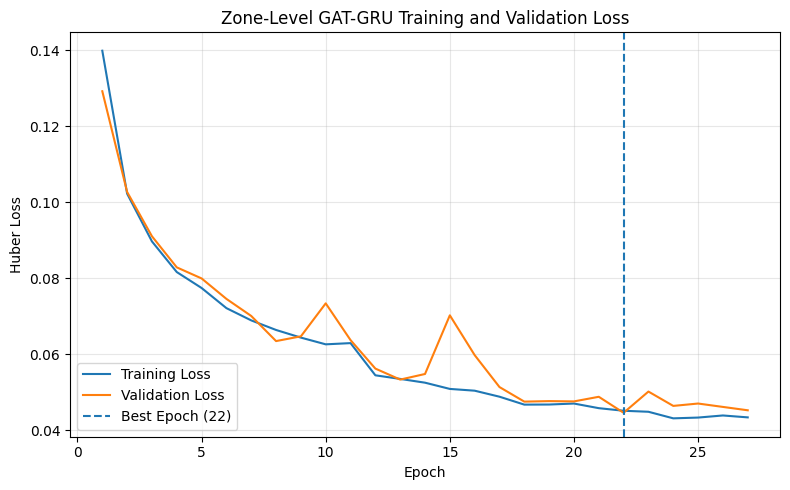

Figure saved: True


In [79]:
# Creating the epoch numbers
epochs = range(1, len(training_losses) + 1)

# Plotting training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_losses,
    label="Validation Loss"
)

# Showing the best validation epoch
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Zone-Level GAT-GRU Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Saving the figure
gat_gru_loss_path = figures_dir / "zone_gat_gru_training_loss.png"

plt.savefig(
    gat_gru_loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", gat_gru_loss_path.exists())

Training and validation loss decreased during learning, with the lowest validation loss occurring at epoch 22 before early stopping ended training.

## Visualising GAT-GRU Actual and Predicted Demand

Comparing observed and predicted total hourly pickup demand across the GAT-GRU test period.

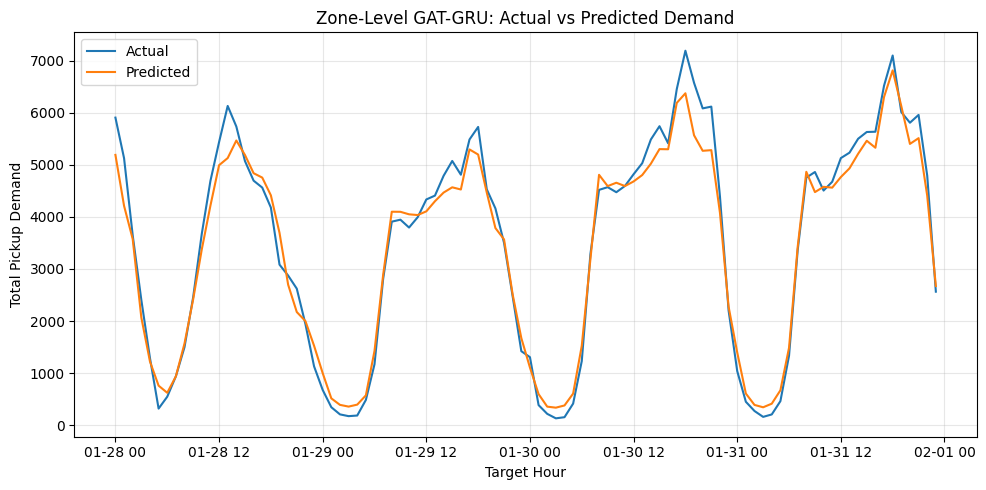

Figure saved: True


In [80]:
# Creating hourly test results
gat_gru_time_results = pd.DataFrame({
    "target_hour": test_target_hours,
    "actual_demand": test_actual.sum(axis=1),
    "predicted_demand": test_predictions.sum(axis=1)
})

# Plotting actual and predicted demand
plt.figure(figsize=(10, 5))

plt.plot(
    gat_gru_time_results["target_hour"],
    gat_gru_time_results["actual_demand"],
    label="Actual"
)

plt.plot(
    gat_gru_time_results["target_hour"],
    gat_gru_time_results["predicted_demand"],
    label="Predicted"
)

plt.xlabel("Target Hour")
plt.ylabel("Total Pickup Demand")
plt.title("Zone-Level GAT-GRU: Actual vs Predicted Demand")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Saving the figure
gat_gru_time_path = figures_dir / "zone_gat_gru_actual_vs_predicted_time.png"

plt.savefig(
    gat_gru_time_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", gat_gru_time_path.exists())

The GAT-GRU captures the overall Manhattan demand pattern well after aggregating predictions across zones. However, the zone-level evaluation metrics show that larger errors remain for individual taxi zones, particularly at low demand levels.

## Visualising GAT-GRU Zone-Level Predictions

Comparing actual and predicted pickup demand across all individual zone-hour observations in the test period.

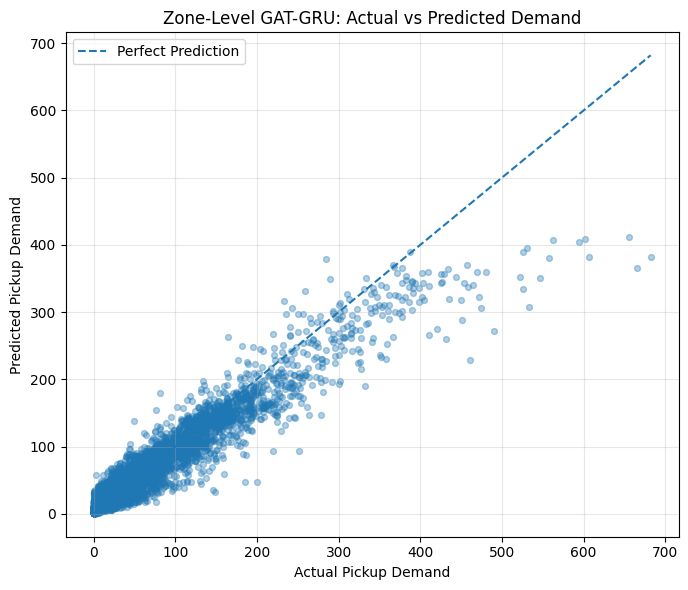

Figure saved: True


In [81]:
# Creating the scatter plot
plt.figure(figsize=(7, 6))

plt.scatter(
    test_actual_flat,
    test_predictions_flat,
    alpha=0.35,
    s=18
)

# Creating the perfect-prediction reference line
max_value = max(
    test_actual_flat.max(),
    test_predictions_flat.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Pickup Demand")
plt.ylabel("Predicted Pickup Demand")
plt.title("Zone-Level GAT-GRU: Actual vs Predicted Demand")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Saving the figure
gat_gru_scatter_path = (
    figures_dir / "zone_gat_gru_actual_vs_predicted_scatter.png"
)

plt.savefig(
    gat_gru_scatter_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", gat_gru_scatter_path.exists())

The GAT-GRU captures the general zone-level demand relationship, but high-demand observations are frequently underestimated, contributing to the weaker individual zone-level error metrics.

## Saving the GAT-GRU Test Predictions

In [82]:
# Creating the final test prediction table
gat_gru_test_predictions = pd.DataFrame({
    "target_hour": np.repeat(
        test_target_hours.to_numpy(),
        len(node_location_ids)
    ),
    "LocationID": np.tile(
        node_location_ids,
        len(test_target_hours)
    ),
    "Zone": np.tile(
        gat_zones["zone"].to_numpy(),
        len(test_target_hours)
    ),
    "actual_demand": test_actual.ravel(),
    "gat_gru_prediction": test_predictions.ravel()
})

# Calculating the absolute prediction error
gat_gru_test_predictions["absolute_error"] = np.abs(
    gat_gru_test_predictions["actual_demand"]
    - gat_gru_test_predictions["gat_gru_prediction"]
)

# Saving the predictions
gat_gru_predictions_path = (
    reports_dir / "zone_gat_gru_test_predictions.csv"
)

gat_gru_test_predictions.to_csv(
    gat_gru_predictions_path,
    index=False
)

# Checking the saved output
print("Prediction rows:", len(gat_gru_test_predictions))
print("Unique test hours:", gat_gru_test_predictions["target_hour"].nunique())
print("Unique zones:", gat_gru_test_predictions["LocationID"].nunique())
print("Predictions saved:", gat_gru_predictions_path.exists())

display(gat_gru_test_predictions.head())

Prediction rows: 6144
Unique test hours: 96
Unique zones: 64
Predictions saved: True


,target_hour,LocationID,Zone,actual_demand,gat_gru_prediction,absolute_error
0,2024-01-28,4,Alphabet City,53.0,45.888313,7.111687
1,2024-01-28,12,Battery Park,0.0,11.272095,11.272095
2,2024-01-28,13,Battery Park City,8.0,8.785110,0.785110
3,2024-01-28,24,Bloomingdale,4.0,14.215340,10.215340
4,2024-01-28,41,Central Harlem,12.0,9.556515,2.443485


## Mapping GAT-GRU Prediction Errors

Mapping the average absolute GAT-GRU prediction error across the 64 Manhattan taxi zones during the test period.

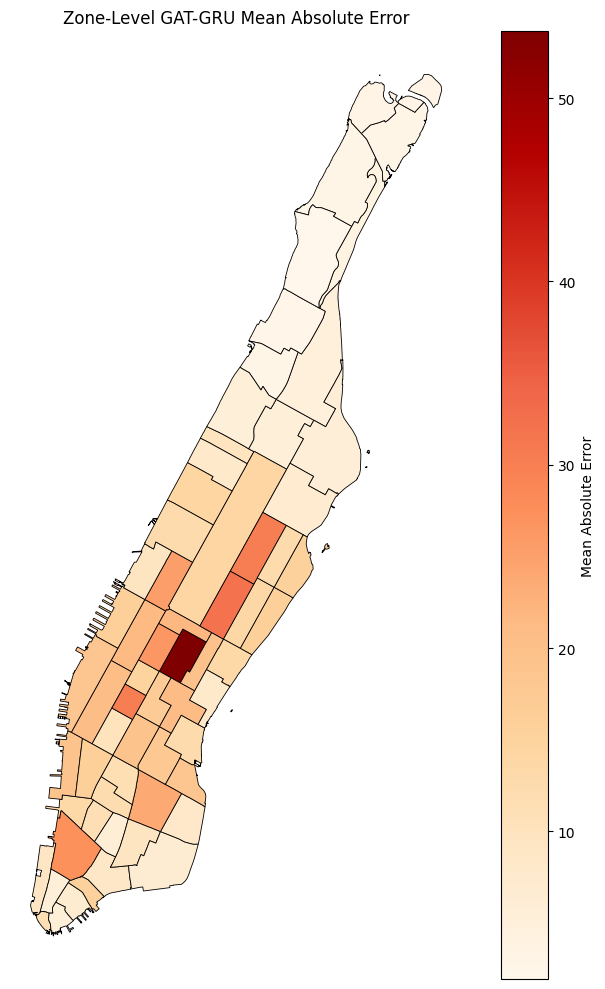

,LocationID,Zone,mean_absolute_error,mean_actual_demand
37,161,Midtown Center,53.639164,209.697922
54,237,Upper East Side South,31.924990,198.041672
43,186,Penn Station/Madison Sq West,30.345129,138.770828
53,236,Upper East Side North,30.278723,192.281250
49,231,TriBeCa/Civic Center,27.268526,50.979168
48,230,Times Sq/Theatre District,26.575487,138.052078
29,142,Lincoln Square East,25.573408,127.104164
13,79,East Village,23.820473,80.531250
39,163,Midtown North,21.859671,124.854164
8,48,Clinton East,21.466970,96.156250


Figure saved: True


In [83]:
# Calculating mean absolute error for each taxi zone
gat_gru_zone_errors = (
    gat_gru_test_predictions
    .groupby(["LocationID", "Zone"], as_index=False)
    .agg(
        mean_absolute_error=("absolute_error", "mean"),
        mean_actual_demand=("actual_demand", "mean")
    )
)

# Joining the errors to the taxi-zone boundaries
gat_gru_error_map = gat_zones.merge(
    gat_gru_zone_errors,
    on="LocationID",
    how="left"
)

# Plotting spatial prediction error
fig, ax = plt.subplots(figsize=(8, 10))

gat_gru_error_map.plot(
    column="mean_absolute_error",
    cmap="OrRd",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={"label": "Mean Absolute Error"}
)

ax.set_title("Zone-Level GAT-GRU Mean Absolute Error")
ax.set_axis_off()

plt.tight_layout()

# Saving the figure
gat_gru_error_map_path = (
    figures_dir / "zone_gat_gru_spatial_absolute_error.png"
)

plt.savefig(
    gat_gru_error_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Showing the zones with the largest absolute errors
display(
    gat_gru_zone_errors
    .sort_values("mean_absolute_error", ascending=False)
    .head(10)
)

print("Figure saved:", gat_gru_error_map_path.exists())

Prediction error varies across Manhattan taxi zones, showing that GAT-GRU accuracy is not spatially uniform. Absolute errors should be interpreted alongside demand levels because busier zones naturally contain larger pickup counts.

## Comparing the Final Zone-Level Models

Comparing the final test performance of all zone-level forecasting models using their calculated predictions.

In [85]:
# Selecting the persistence test observations
persistence_test_data = zone_model_data[
    (zone_model_data["target_hour"] >= test_start)
    & (zone_model_data["target_hour"] < test_end)
].copy()

# Recalculating each model's test metrics directly from predictions
persistence_test_metrics = evaluate_forecast(
    persistence_test_data[target_col].to_numpy(),
    persistence_test_data["pickup_count"].to_numpy()
)

rf_test_metrics = evaluate_forecast(
    rf_test_predictions[target_col].to_numpy(),
    rf_test_predictions["rf_prediction"].to_numpy()
)

lstm_test_metrics = evaluate_forecast(
    lstm_test_predictions["actual_demand"].to_numpy(),
    lstm_test_predictions["lstm_prediction"].to_numpy()
)

gat_gru_test_metrics = evaluate_forecast(
    gat_gru_test_predictions["actual_demand"].to_numpy(),
    gat_gru_test_predictions["gat_gru_prediction"].to_numpy()
)

# Creating the final comparison table
zone_model_comparison = pd.DataFrame(
    {
        "Persistence": persistence_test_metrics,
        "Random Forest": rf_test_metrics,
        "LSTM": lstm_test_metrics,
        "GAT-GRU": gat_gru_test_metrics
    }
).T

# Sorting models by MAE
zone_model_comparison = zone_model_comparison.sort_values("MAE")

print("Final zone-level test comparison:")
display(zone_model_comparison.round(4))

print("\nBest model by MAE:",zone_model_comparison.index[0])

Final zone-level test comparison:


,MAE,RMSE,R2,WMAPE,MAPE_nonzero
Random Forest,9.1915,17.4869,0.9520,16.8524,41.0734
LSTM,9.3782,16.7557,0.9559,17.1947,48.9136
GAT-GRU,13.7366,23.9438,0.9099,25.1858,102.6639
Persistence,14.0645,26.8789,0.8865,25.7869,58.9405



Best model by MAE: Random Forest


Random Forest achieved the strongest overall zone-level performance, while LSTM produced the lowest RMSE and highest R². GAT-GRU improved on persistence for several metrics but did not outperform the simpler Random Forest or LSTM models.

## Saving the Final Zone-Level Metrics


In [86]:
# Creating the GAT-GRU validation and test metrics table
gat_gru_metrics = pd.DataFrame([
    {"Split": "Validation", **validation_metrics},
    {"Split": "Test", **gat_gru_test_metrics}
])

# Preparing the complete zone-level test comparison
zone_comparison_to_save = (
    zone_model_comparison
    .reset_index()
    .rename(columns={"index": "Model"})
)

# Setting output paths
gat_gru_metrics_path = reports_dir / "zone_gat_gru_metrics_1h_2024_01.csv"
zone_comparison_path = reports_dir / "zone_model_comparison_1h_2024_01.csv"

# Saving the results
gat_gru_metrics.to_csv(gat_gru_metrics_path, index=False)
zone_comparison_to_save.to_csv(zone_comparison_path, index=False)

# Checking saved files
print("GAT-GRU metrics saved:", gat_gru_metrics_path.exists())
print("Zone comparison saved:", zone_comparison_path.exists())
print("Models saved in comparison:", len(zone_comparison_to_save))

GAT-GRU metrics saved: True
Zone comparison saved: True
Models saved in comparison: 4


## Visualising the Final Zone-Level Model Performance

Comparing test-set WMAPE across Persistence, Random Forest, LSTM and GAT-GRU.

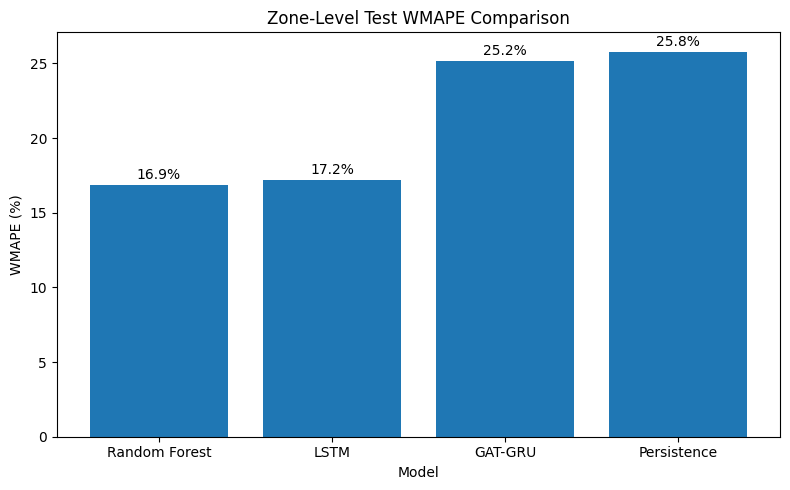

Figure saved: True


In [87]:
# Sorting models by WMAPE
comparison_plot_data = (zone_model_comparison.sort_values("WMAPE"))

# Creating the comparison plot
plt.figure(figsize=(8, 5))

plt.bar(comparison_plot_data.index,comparison_plot_data["WMAPE"])

plt.ylabel("WMAPE (%)")
plt.xlabel("Model")
plt.title("Zone-Level Test WMAPE Comparison")

# Adding values above the bars
for index, value in enumerate(comparison_plot_data["WMAPE"]):
    plt.text(
        index,
        value + 0.4,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

# Saving the figure
zone_comparison_figure_path = (figures_dir / "zone_model_wmape_comparison.png")

plt.savefig(
    zone_comparison_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", zone_comparison_figure_path.exists())

## Summarising the Zone-Level Results

Random Forest performed best overall, while LSTM achieved the lowest RMSE and highest R². GAT-GRU captured the general demand pattern but was less accurate at individual zone level.